###Import Libraries

In [ ]:
import re
import numpy as np
import pandas as pd

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Environment ready.")

Environment ready.


###Load Datasets

In [ ]:
import pandas as pd

# Upload public_dataset.csv and scrapped.csv to your Colab session files
# Or upload using:
# from google.colab import files
# uploaded = files.upload()

df_public = pd.read_csv('https://raw.githubusercontent.com/sheikhsarafathossain/laptopchai/main/Datasets/public_dataset.csv?raw=true', encoding='latin1')
df_scrapped = pd.read_csv('https://raw.githubusercontent.com/sheikhsarafathossain/laptopchai/main/Datasets/scrapped.csv?raw=true', encoding='latin1')


print(f"Public dataset initial rows: {len(df_public)}")
print(f"Scrapped dataset initial rows: {len(df_scrapped)}")

Public dataset initial rows: 1303
Scrapped dataset initial rows: 621


###Data Cleaning Functions

In [ ]:
def clean_company(val):
    if pd.isna(val):
        return "Other"
    v = str(val).strip()
    brand_map = {
        'acer': 'Acer', 'asus': 'Asus', 'hp': 'HP', 'lenovo': 'Lenovo',
        'dell': 'Dell', 'apple': 'Apple', 'msi': 'MSI', 'samsung': 'Samsung',
        'microsoft': 'Microsoft', 'walton': 'Walton', 'tecno': 'Tecno',
        'smart': 'Smart', 'gigabyte': 'Gigabyte', 'thunderobot': 'Thunderobot',
        'chuwi': 'Chuwi', 'toshiba': 'Toshiba', 'huawei': 'Huawei',
        'xiaomi': 'Xiaomi', 'razer': 'Razer', 'mediacom': 'Mediacom',
        'google': 'Google', 'lg': 'LG', 'fujitsu': 'Fujitsu', 'vero': 'Vero'
    }
    return brand_map.get(v.lower(), v.title())

def clean_product(val, company):
    if pd.isna(val):
        return "Laptop"
    p = str(val).strip().replace('"', '')
    # Remove leading company duplicate
    p = re.sub(rf'^{re.escape(str(company))}\s+', '', p, flags=re.IGNORECASE).strip()
    # Remove cluttering tags
    p = re.sub(r'\(Certified Refurbished\)', '', p, flags=re.IGNORECASE)
    p = re.sub(r'\d+GB\s+RAM.*', '', p, flags=re.IGNORECASE)
    p = re.sub(r'\d+GB\s+DDR\d.*', '', p, flags=re.IGNORECASE)
    return p.strip(' -,') if p.strip(' -,') else "Laptop"

def clean_typename(val, product_name, gpu):
    text = f"{val} {product_name} {gpu}".lower()
    if any(k in text for k in ['gaming', 'rtx ', 'gtx ', 'legion', 'tuf', 'victus', 'nitro', 'cyborg', 'katana', 'strix', 'omen', 'predator', 'aorus', 'alienware']):
        return "Gaming"
    if any(k in text for k in ['2 in 1', '2-in-1', 'convertible', 'flip', 'x360', 'yoga', 'duo']):
        return "2 in 1 Convertible"
    if any(k in text for k in ['ultrabook', 'zenbook', 'macbook', 'swift', 'surface', 'slim', 'carbon', 'prestige']):
        return "Ultrabook"
    if any(k in text for k in ['workstation', 'zbook', 'precision', 'thinkpad p', 'proart']):
        return "Workstation"
    if any(k in text for k in ['netbook', 'chromebook']):
        return "Netbook"
    return "Notebook"

def clean_inches(val):
    try:
        return round(float(val), 1)
    except:
        return 15.6

def clean_screen_resolution(val):
    if pd.isna(val):
        return "Full HD 1920x1080"
    s = str(val).strip()
    res_match = re.search(r'(\d{3,4}\s*[xX×]\s*\d{3,4})', s)
    res = res_match.group(1).lower().replace(' ', '').replace('×', 'x') if res_match else "1920x1080"

    is_ips = bool(re.search(r'\bIPS\b', s, re.IGNORECASE))
    is_touch = bool(re.search(r'\bTouch(?:screen)?\b', s, re.IGNORECASE))
    is_retina = bool(re.search(r'\bRetina\b', s, re.IGNORECASE))
    is_oled = bool(re.search(r'\bOLED\b|\bAMOLED\b', s, re.IGNORECASE))
    is_4k = bool(re.search(r'\b4K\b|\bUHD\b', s, re.IGNORECASE)) or '3840' in res
    is_qhd = bool(re.search(r'\bQHD\b|\b2\.5K\b|\b2\.8K\b|\bWQXGA\b|\b2K\b', s, re.IGNORECASE))

    parts = []
    if is_ips:
        parts.append("IPS Panel")
    if is_retina:
        parts.append("Retina Display")
    elif is_oled:
        parts.append("OLED Display")
    elif is_4k:
        parts.append("4K Ultra HD")
    elif is_qhd:
        parts.append("Quad HD+")
    else:
        if '1920x1080' in res or '1920x1200' in res:
            parts.append("Full HD")

    if is_touch:
        parts.append("/ Touchscreen" if parts else "Touchscreen")

    prefix = " ".join(parts).strip()
    return f"{prefix} {res}".strip() if prefix else f"Full HD {res}"

def clean_cpu(val):
    if pd.isna(val):
        return "Intel Core i5"
    c = str(val).strip()
    if 'Chipset:' in c or 'CPU:' in c:
        chip_match = re.search(r'Chipset:\s*([^\|]+)', c)
        cpu_match = re.search(r'CPU:\s*([^\|]+)', c)
        chip = chip_match.group(1).strip() if chip_match else "Apple M5"
        cores = cpu_match.group(1).strip() if cpu_match else ""
        return f"{chip} {cores}".strip()

    c = c.rstrip(',').strip()
    c = re.sub(r'\s*Processor.*', '', c, flags=re.IGNORECASE)
    c = re.sub(r'\s*,?\s*up to.*', '', c, flags=re.IGNORECASE)
    c = re.sub(r'\s*with NPU.*', '', c, flags=re.IGNORECASE)
    c = re.sub(r'\s*With Max.*', '', c, flags=re.IGNORECASE)
    return c

def clean_ram(val):
    if pd.isna(val):
        return "8GB"
    r = str(val).strip().upper()
    match = re.search(r'(\d+)\s*GB', r)
    return f"{match.group(1)}GB" if match else "8GB"

def clean_memory(val):
    if pd.isna(val):
        return "512GB SSD"
    m = str(val).strip()
    match = re.search(r'(\d+(?:GB|TB))\s*(SSD|HDD|Flash Storage)', m, re.IGNORECASE)
    if match:
        stype = "Flash Storage" if match.group(2).upper() == "FLASH STORAGE" else match.group(2).upper()
        return f"{match.group(1).upper()} {stype}"
    return m

def clean_gpu(val):
    if pd.isna(val):
        return "Intel UHD Graphics"
    g = str(val).strip()
    if re.search(r'RTX\s*\d+', g, re.IGNORECASE) and not g.lower().startswith('nvidia'):
        g = re.sub(r'(?:Nvidia\s+|NVIDIA\s+)?', 'Nvidia GeForce ', g, flags=re.IGNORECASE).strip()
    elif 'Iris' in g:
        g = "Intel Iris Xe Graphics"
    elif 'Intel Arc' in g or 'Arc Graphics' in g:
        g = "Intel Arc Graphics"
    elif 'Intel UHD' in g or 'Intel Graphics' in g:
        g = "Intel UHD Graphics"
    elif 'Radeon' in g:
        g = "AMD Radeon Graphics"
    elif 'Adreno' in g:
        g = "Qualcomm Adreno Graphics"
    elif 'Core GPU' in g or 'core GPU' in g:
        match = re.search(r'(\d+)[‑\-\s]*Core\s*GPU', g, re.IGNORECASE)
        g = f"Apple {match.group(1)}-Core GPU" if match else "Apple Integrated GPU"
    return g

def clean_opsys(val, company):
    if pd.isna(val):
        return "macOS" if company == 'Apple' else "Windows 11"
    o = str(val).strip()
    if company == 'Apple':
        return "macOS"
    if 'win' in o.lower() and '10' in o:
        return "Windows 10"
    if 'win' in o.lower() or 'copilot' in o.lower():
        return "Windows 11"
    if 'no os' in o.lower() or 'freedos' in o.lower():
        return "No OS"
    if 'linux' in o.lower():
        return "Linux"
    if 'chrome' in o.lower():
        return "Chrome OS"
    return o

def clean_weight(val):
    if pd.isna(val):
        return "1.8kg"
    w = str(val).strip().lower()
    match = re.search(r'(\d+(?:\.\d+)?)\s*kg', w)
    return f"{float(match.group(1))}kg" if match else "1.8kg"

def clean_price(val, exchange_rate=130.0):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().upper()
    if v in ['TBA', '0', '0.0', 'NULL', 'NONE', 'NAN', '']:
        return np.nan
    clean_str = re.sub(r'[^0-9.]', '', v)
    try:
        bdt_price = float(clean_str)
        if bdt_price <= 0:
            return np.nan
        # Convert BDT to Euros
        return round(bdt_price / exchange_rate, 2)
    except:
        return np.nan

###Clean and Align Scraped Dataset

In [ ]:
df_s = df_scrapped.copy()

# 1. Filter out invalid prices (TBA, 0, Null)
df_s['Price_euros'] = df_s['Price'].apply(lambda x: clean_price(x, exchange_rate=130.0))
df_s = df_s.dropna(subset=['Price_euros'])

# 2. Apply cleaning pipelines
df_s['Company'] = df_s['Company'].apply(clean_company)
df_s['Product'] = df_s.apply(lambda r: clean_product(r['Product'], r['Company']), axis=1)
df_s['TypeName'] = df_s.apply(lambda r: clean_typename(r['TypeName'], r['Product'], r['Gpu']), axis=1)
df_s['Inches'] = df_s['Inches'].apply(clean_inches)
df_s['ScreenResolution'] = df_s['ScreenResolution'].apply(clean_screen_resolution)
df_s['Cpu'] = df_s['Cpu']
df_s['Ram'] = df_s['Ram']
df_s['Memory'] = df_s['Memory']
df_s['Gpu'] = df_s['Gpu']
df_s['OpSys'] = df_s.apply(lambda r: clean_opsys(r['OpSys'], r['Company']), axis=1)
df_s['Weight'] = df_s['Weight'].apply(clean_weight)

# Align columns with public dataset
target_cols = [
    'laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
    'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros'
]
df_s_cleaned = df_s[target_cols].copy()

print(f"Scrapped records after cleaning and price filtering: {len(df_s_cleaned)}")
df_s_cleaned.head()

Scrapped records after cleaning and price filtering: 572


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Acer,Nitro V15 ANV15-52-57BB,Gaming,15.6,Full HD 1920x1080,Intel Core i5-13420H,8GB,512GB SSD,NVIDIA GeForce RTX 5050,Windows 11,1.99kg,984.62
1,2,Asus,TUF Gaming A15 FA506NCG,Gaming,15.6,IPS Panel Full HD 1920x1080,AMD Ryzen 7-7445HS,4GB,512GB SSD,NVIDIA GeForce RTX 3050,Windows 11,2.3kg,907.69
2,3,HP,15-fc0146dx,Ultrabook,15.6,IPS Panel Full HD / Touchscreen 1920x1080,AMD Ryzen 5 7520U,8GB,512GB SSD,AMD Radeon Graphics,Windows 11,1.6kg,515.31
3,4,HP,OmniBook 5 Flip 14-fp0023dx,2 in 1 Convertible,14.0,IPS Panel Quad HD+ 1920x1200,Intel Core 7-150U,16GB,512GB SSD,Intel UHD Graphics,Windows 11,1.3kg,999.23
4,5,HP,Victus 15-FA2013DX,Gaming,15.6,Full HD 1920x1080,Intel Core i5-13420H,6GB,512GB SSD,NVIDIA GeForce RTX 3050 Laptop GPU,Windows 11,2.3kg,746.15


###Merge Datasets

In [ ]:
# Align public dataset
df_p = df_public[target_cols].copy()
df_p['Inches'] = df_p['Inches'].astype(float)
df_p['Price_euros'] = df_p['Price_euros'].astype(float)

# Merge datasets
df_merged = pd.concat([df_p, df_s_cleaned], ignore_index=True)

# Re-assign clean sequential laptop_ID (1 to N)
df_merged['laptop_ID'] = np.arange(1, len(df_merged) + 1)

print(f"Public dataset records:   {len(df_p)}")
print(f"Scrapped cleaned records: {len(df_s_cleaned)}")
print(f"Total merged records:     {len(df_merged)}")

Public dataset records:   1303
Scrapped cleaned records: 572
Total merged records:     1875


###Validate and Export Datasets

In [ ]:
# Missing value check
print("Missing values in merged dataset:")
print(df_merged.isnull().sum())

# Export files
df_s_cleaned.to_csv('cleaned_scrapped.csv', index=False)
df_merged.to_csv('merged_laptops_dataset.csv', index=False)

print("\nFiles successfully created and saved:")
print("- cleaned_scrapped.csv")
print("- merged_laptops_dataset.csv")

Missing values in merged dataset:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

Files successfully created and saved:
- cleaned_scrapped.csv
- merged_laptops_dataset.csv


###Dataset Overview

In [ ]:
print("=== Brand Count ===")
print(df_merged['Company'].value_counts().head(10))

print("\n=== Type Distribution ===")
print(df_merged['TypeName'].value_counts())

print("\n=== Price Statistics (in Euros) ===")
print(df_merged['Price_euros'].describe().round(2))

print("\n=== Merged Dataset Sample ===")
df_merged.tail(5)

=== Brand Count ===
Company
Lenovo       454
HP           346
Asus         325
Dell         313
Acer         143
MSI           89
Apple         72
Toshiba       48
Microsoft     19
Samsung        9
Name: count, dtype: int64

=== Type Distribution ===
TypeName
Notebook              879
Ultrabook             398
Gaming                370
2 in 1 Convertible    173
Workstation            30
Netbook                25
Name: count, dtype: int64

=== Price Statistics (in Euros) ===
count    1875.00
mean     1187.57
std       784.88
min       174.00
25%       650.00
50%       984.62
75%      1499.00
max      6230.77
Name: Price_euros, dtype: float64

=== Merged Dataset Sample ===


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1870,1871,Asus,ROG Strix SCAR 18 (2025) G835LX,Gaming,18.0,OLED Display 2560x1600,Intel Core Ultra 9 275HX,24GB,1TB SSD,RTX 5090,Windows 11,3.48kg,4999.23
1871,1872,Apple,MacBook Pro M5 Max,Ultrabook,16.0,Retina Display / Touchscreen 3024x1964,Apple M5 Pro chip,36GB,2TB SSD,32-core GPU,macOS,2.15kg,5038.46
1872,1873,Acer,Predator Helios Neo 16 AI-PH16-73,Gaming,16.0,OLED Display 1920x1080,Intel Core Ultra 9 275HX,24GB,2TB SSD,NVIDIA RTX 5090,Windows 11,2.3kg,5076.92
1873,1874,Apple,MacBook Pro M5 Max,Ultrabook,16.0,Retina Display / Touchscreen 3024x1964,Apple M5 Pro chip,48GB,2TB SSD,40-core GPU,macOS,2.15kg,5615.38
1874,1875,Asus,ROG Zephyrus Duo 16 GX651AX,Gaming,16.0,OLED Display / Touchscreen 2880x1800,Intel Core Ultra 9 386H up to 50TOPS,24GB,2TB SSD,RTX 5090,Windows 11,2.82kg,6230.77


###Dataset Visualization

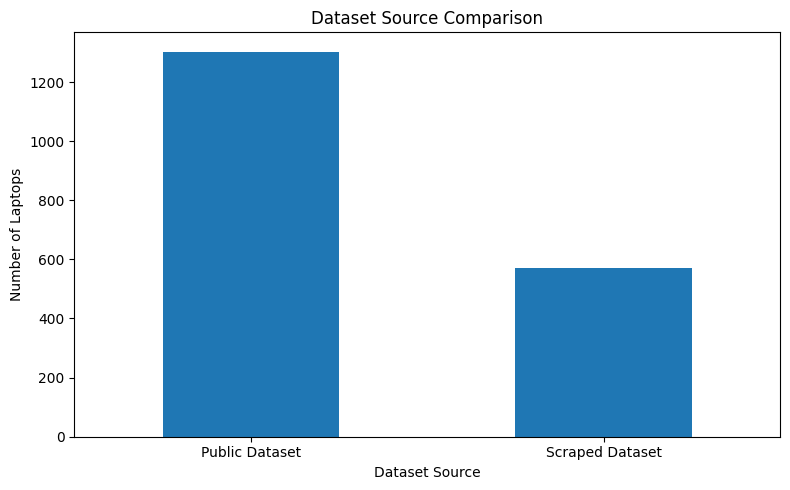

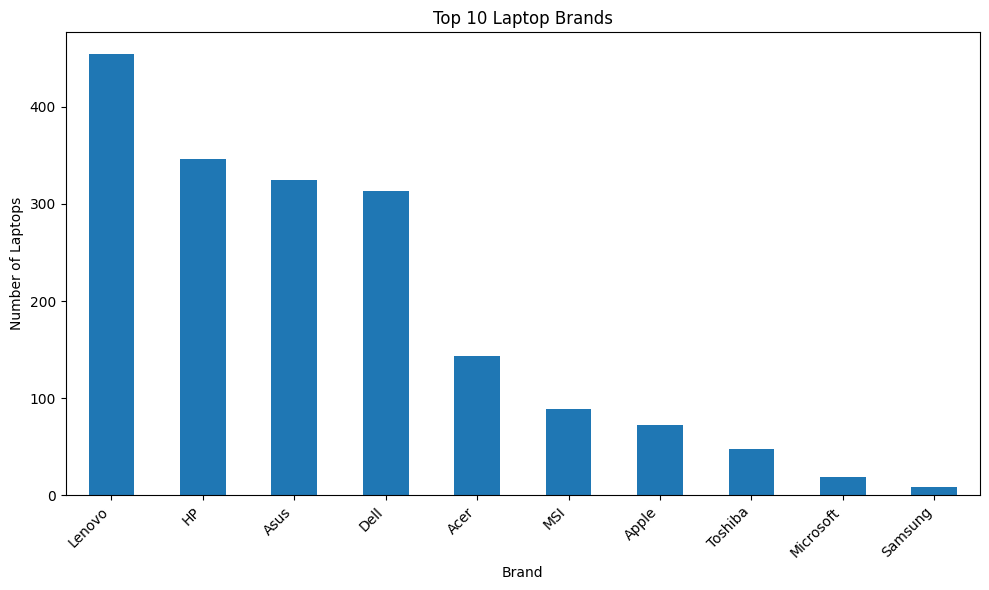

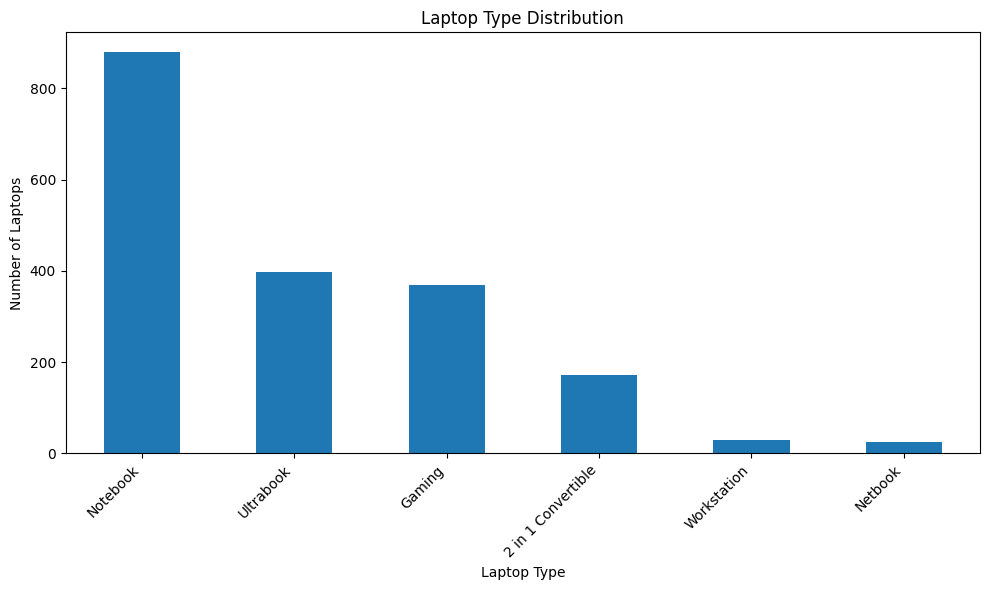

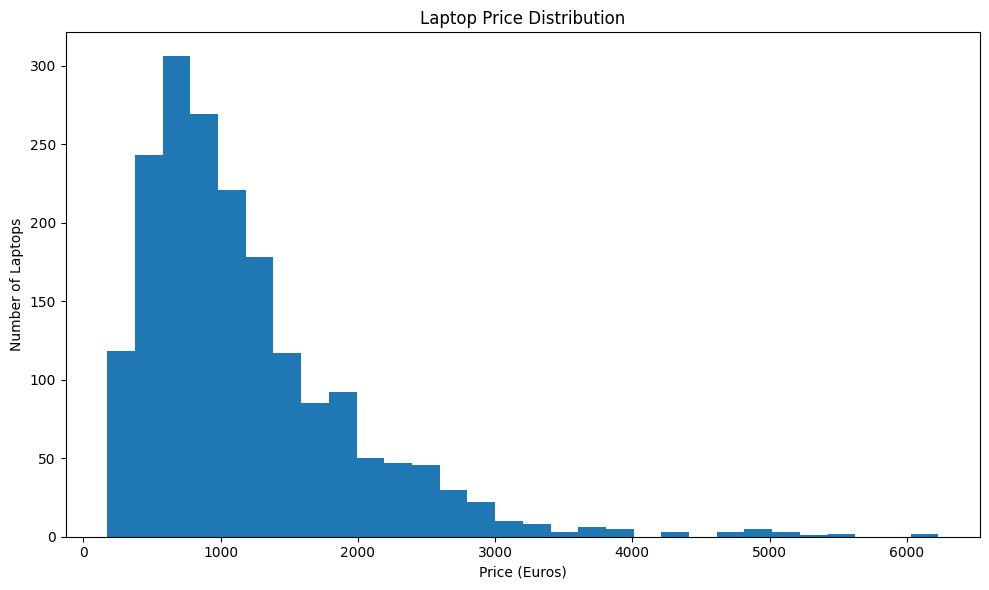

In [ ]:
import matplotlib.pyplot as plt

# 1. Dataset Source Comparison
source_counts = pd.Series({
    'Public Dataset': len(df_p),
    'Scraped Dataset': len(df_s_cleaned)
})

plt.figure(figsize=(8, 5))
source_counts.plot(kind='bar')
plt.title('Dataset Source Comparison')
plt.xlabel('Dataset Source')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 2. Top 10 Brand Distribution
top_brands = df_merged['Company'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_brands.plot(kind='bar')
plt.title('Top 10 Laptop Brands')
plt.xlabel('Brand')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3. Laptop Type Distribution
type_counts = df_merged['TypeName'].value_counts()

plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar')
plt.title('Laptop Type Distribution')
plt.xlabel('Laptop Type')
plt.ylabel('Number of Laptops')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 4. Price Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_merged['Price_euros'], bins=30)
plt.title('Laptop Price Distribution')
plt.xlabel('Price (Euros)')
plt.ylabel('Number of Laptops')
plt.tight_layout()
plt.show()

###Install Required Packages

In [ ]:
# Install PySpark, Sentence-Transformers, and PyArrow in Colab
!pip install -q pyspark sentence-transformers pyarrow

###Initialize Spark Session

In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, udf, pandas_udf, explode, array, concat_ws,
    trim, lower, when, lit, regexp_replace, round as spark_round,
    monotonically_increasing_id
)
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, FloatType, ArrayType
)
from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram, CountVectorizer, MinHashLSH
from pyspark.sql.window import Window
import pandas as pd

# Create an optimized local Spark session
spark = SparkSession.builder \
    .appName("CSE488_Spark_RAG_Pipeline") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print(f"Apache Spark Version: {spark.version}")

Apache Spark Version: 4.0.4


###Spark Data Preprocessing

In [ ]:
# Load the cleaned merged dataset from Step 3.1
raw_df = spark.read.csv(
    "merged_laptops_dataset.csv",
    header=True,
    inferSchema=True
)

# 1. Clean & Cast columns using Spark DataFrame API
clean_df = raw_df \
    .withColumn("laptop_ID", col("laptop_ID").cast(IntegerType())) \
    .withColumn("Company", trim(col("Company"))) \
    .withColumn("Product", trim(col("Product"))) \
    .withColumn("TypeName", trim(col("TypeName"))) \
    .withColumn("Inches", col("Inches").cast(DoubleType())) \
    .withColumn("ScreenResolution", trim(col("ScreenResolution"))) \
    .withColumn("Cpu", trim(col("Cpu"))) \
    .withColumn("Ram", trim(col("Ram"))) \
    .withColumn("Memory", trim(col("Memory"))) \
    .withColumn("Gpu", trim(col("Gpu"))) \
    .withColumn("OpSys", trim(col("OpSys"))) \
    .withColumn("Weight", trim(col("Weight"))) \
    .withColumn("Price_euros", spark_round(col("Price_euros").cast(DoubleType()), 2))

# 2. Filter invalid or null rows
clean_df = clean_df.filter(
    col("Price_euros").isNotNull() & (col("Price_euros") > 0) & col("Product").isNotNull()
)

# 3. Synthesize rich specification text for similarity analysis and retrieval
clean_df = clean_df.withColumn(
    "full_spec_text",
    concat_ws(
        " | ",
        concat_ws(" ", col("Company"), col("Product")),
        concat_ws(": ", lit("Category"), col("TypeName")),
        concat_ws(": ", lit("Display"), concat_ws(" inch ", col("Inches").cast(StringType()), col("ScreenResolution"))),
        concat_ws(": ", lit("Processor"), col("Cpu")),
        concat_ws(": ", lit("RAM"), col("Ram")),
        concat_ws(": ", lit("Storage"), col("Memory")),
        concat_ws(": ", lit("Graphics"), col("Gpu")),
        concat_ws(": ", lit("OS"), col("OpSys")),
        concat_ws(": ", lit("Weight"), col("Weight")),
        concat_ws(": ", lit("Price"), concat_ws(" EUR", col("Price_euros").cast(StringType())))
    )
)

print(f"Total cleaned devices in Spark: {clean_df.count()}")
clean_df.select("laptop_ID", "Company", "Product", "Price_euros", "full_spec_text").show(3, truncate=80)

Total cleaned devices in Spark: 1875
+---------+-------+-----------+-----------+--------------------------------------------------------------------------------+
|laptop_ID|Company|    Product|Price_euros|                                                                  full_spec_text|
+---------+-------+-----------+-----------+--------------------------------------------------------------------------------+
|        1|  Apple|MacBook Pro|    1339.69|Apple MacBook Pro | Category: Ultrabook | Display: 13.3 inch IPS Panel Retina...|
|        2|  Apple|Macbook Air|     898.94|Apple Macbook Air | Category: Ultrabook | Display: 13.3 inch 1440x900 | Proce...|
|        3|     HP|     250 G6|      575.0|HP 250 G6 | Category: Notebook | Display: 15.6 inch Full HD 1920x1080 | Proce...|
+---------+-------+-----------+-----------+--------------------------------------------------------------------------------+
only showing top 3 rows


###MinHash LSH Deduplication

In [ ]:
# 1. Tokenize specification text
tokenizer = Tokenizer(inputCol="full_spec_text", outputCol="raw_tokens")
tokenized_df = tokenizer.transform(clean_df)

# 2. Remove standard stopwords
remover = StopWordsRemover(inputCol="raw_tokens", outputCol="filtered_tokens")
filtered_df = remover.transform(tokenized_df)

# 3. Create 3-word shingles for lexical overlap
ngram = NGram(n=3, inputCol="filtered_tokens", outputCol="ngrams")
ngram_df = ngram.transform(filtered_df)

# 4. CountVectorizer to create sparse term frequency feature vectors
cv = CountVectorizer(inputCol="ngrams", outputCol="features", minDF=1.0)
cv_model = cv.fit(ngram_df)
vectorized_df = cv_model.transform(ngram_df)

# 5. Fit MinHash LSH model
minhash = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=5, seed=42)
lsh_model = minhash.fit(vectorized_df)

# Transform to get minhash buckets
hashed_df = lsh_model.transform(vectorized_df)

# 6. Find near-duplicate pairs within Jaccard distance threshold <= 0.15
similarity_pairs = lsh_model.approxSimilarityJoin(
    hashed_df, hashed_df, threshold=0.15, distCol="JaccardDistance"
).filter("datasetA.laptop_ID < datasetB.laptop_ID")

print(f"Near-duplicate pairs detected: {similarity_pairs.count()}")
similarity_pairs.select(
    col("datasetA.laptop_ID").alias("id_A"),
    col("datasetA.Product").alias("product_A"),
    col("datasetB.laptop_ID").alias("id_B"),
    col("datasetB.Product").alias("product_B"),
    col("JaccardDistance")
).show(5, truncate=40)

# 7. Deduplicate: collect duplicate IDs to drop (keeping the canonical first occurrence)
duplicate_ids_to_drop = [
    row["laptop_ID"] for row in similarity_pairs.select("datasetB.laptop_ID").distinct().collect()
]

deduped_df = clean_df.filter(~col("laptop_ID").isin(duplicate_ids_to_drop))
print(f"Devices after MinHash LSH deduplication: {deduped_df.count()} (Dropped {len(duplicate_ids_to_drop)} near-duplicates)")

Near-duplicate pairs detected: 159
+----+-----------------------------------+----+-----------------------------------+--------------------+
|id_A|                          product_A|id_B|                          product_B|     JaccardDistance|
+----+-----------------------------------+----+-----------------------------------+--------------------+
|  51|                          Yoga Book|1115|                          Yoga Book|0.045454545454545414|
|1262|               ZenBook UX305CA-UBM1|1276|               ZenBook UX305CA-UBM1|                 0.0|
|1676|                Vivobook 14 A1404VA|1677|                Vivobook 14 A1404VA|                 0.0|
|1275|X553SA-XX031T (N3050/4GB/500GB/W10)|1289|X553SA-XX031T (N3050/4GB/500GB/W10)|                 0.0|
|1439|             VivoBook Go 14 E1404FA|1440|             VivoBook Go 14 E1404FA|                 0.0|
+----+-----------------------------------+----+-----------------------------------+--------------------+
only showing top 5 r

###Text Chunking

In [ ]:
def chunk_laptop_text(spec_text, chunk_size=180, overlap=30):
    """
    Splits text into overlapping chunks of word tokens.
    Returns list of formatted chunk strings.
    """
    if not spec_text:
        return []
    words = spec_text.split()
    if len(words) <= chunk_size:
        return [spec_text]

    chunks = []
    step = chunk_size - overlap
    for i in range(0, len(words), step):
        chunk = " ".join(words[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks

# Register chunking UDF
chunk_udf = udf(lambda text: chunk_laptop_text(text, chunk_size=40, overlap=10), ArrayType(StringType()))

# Apply chunking UDF and explode array into distinct rows
chunked_df = deduped_df.withColumn("chunks_array", chunk_udf(col("full_spec_text"))) \
    .withColumn("chunk_text", explode(col("chunks_array"))) \
    .drop("chunks_array")

# Add a unique sequential chunk_id
chunk_window = Window.orderBy("laptop_ID")
chunked_df = chunked_df.withColumn("chunk_id", monotonically_increasing_id())

print(f"Total chunked records for embedding: {chunked_df.count()}")
chunked_df.select("chunk_id", "laptop_ID", "Company", "Product", "chunk_text").show(3, truncate=80)

Total chunked records for embedding: 3396
+--------+---------+-------+-----------+--------------------------------------------------------------------------------+
|chunk_id|laptop_ID|Company|    Product|                                                                      chunk_text|
+--------+---------+-------+-----------+--------------------------------------------------------------------------------+
|       0|        1|  Apple|MacBook Pro|Apple MacBook Pro | Category: Ultrabook | Display: 13.3 inch IPS Panel Retina...|
|       1|        1|  Apple|MacBook Pro|      Intel Iris Plus Graphics 640 | OS: macOS | Weight: 1.37kg | Price: 1339.69|
|       2|        2|  Apple|Macbook Air|Apple Macbook Air | Category: Ultrabook | Display: 13.3 inch 1440x900 | Proce...|
+--------+---------+-------+-----------+--------------------------------------------------------------------------------+
only showing top 3 rows


###Distributed Embedding Generation

In [ ]:
@pandas_udf(ArrayType(FloatType()))
def generate_embeddings_udf(texts: pd.Series) -> pd.Series:
    """
    Batched distributed sentence-transformer embedding generation.
    Runs locally on each worker partition.
    """
    from sentence_transformers import SentenceTransformer

    # Load model per partition/worker
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

    # Batch encode texts with L2 normalization for cosine similarity
    embeddings = model.encode(
        texts.tolist(),
        batch_size=64,
        show_progress_bar=False,
        normalize_embeddings=True
    )

    # Convert numpy array output to list of float lists
    return pd.Series(embeddings.tolist())

# Generate dense vector embeddings distributed across Spark partitions
embedded_df = chunked_df.withColumn("embedding", generate_embeddings_udf(col("chunk_text")))

embedded_df.select("chunk_id", "laptop_ID", "Product", "embedding").show(2, truncate=60)

+--------+---------+-----------+------------------------------------------------------------+
|chunk_id|laptop_ID|    Product|                                                   embedding|
+--------+---------+-----------+------------------------------------------------------------+
|       0|        1|MacBook Pro|[0.016528873, -0.031766456, -0.03238905, -0.009538435, 0....|
|       1|        1|MacBook Pro|[-0.02701959, -0.015560327, -0.011032166, 0.01768907, 0.0...|
+--------+---------+-----------+------------------------------------------------------------+
only showing top 2 rows


###Save Embeddings to Parquet

In [ ]:
output_path = "laptops_embedded_chunks.parquet"

# Write embeddings and metadata to Parquet
embedded_df.write \
    .mode("overwrite") \
    .parquet(output_path)

print(f"Parquet dataset written successfully to: {output_path}")

# Read back and verify schema and row count
verification_df = spark.read.parquet(output_path)
print(f"\nVerification:")
print(f"- Total rows stored: {verification_df.count()}")
print(f"- Schema:")
verification_df.printSchema()

# Inspect sample embedding vector size
sample_vector = verification_df.select("embedding").first()["embedding"]
print(f"\nEmbedding dimensionality: {len(sample_vector)} (Expected: 384 for all-MiniLM-L6-v2)")

Parquet dataset written successfully to: laptops_embedded_chunks.parquet

Verification:
- Total rows stored: 3396
- Schema:
root
 |-- laptop_ID: integer (nullable = true)
 |-- Company: string (nullable = true)
 |-- Product: string (nullable = true)
 |-- TypeName: string (nullable = true)
 |-- Inches: double (nullable = true)
 |-- ScreenResolution: string (nullable = true)
 |-- Cpu: string (nullable = true)
 |-- Ram: string (nullable = true)
 |-- Memory: string (nullable = true)
 |-- Gpu: string (nullable = true)
 |-- OpSys: string (nullable = true)
 |-- Weight: string (nullable = true)
 |-- Price_euros: double (nullable = true)
 |-- full_spec_text: string (nullable = true)
 |-- chunk_text: string (nullable = true)
 |-- chunk_id: long (nullable = true)
 |-- embedding: array (nullable = true)
 |    |-- element: float (containsNull = true)


Embedding dimensionality: 384 (Expected: 384 for all-MiniLM-L6-v2)


###ChromaDB Vector Storage

In [ ]:
!pip install -q chromadb pyarrow pandas

import chromadb
import pandas as pd
import numpy as np

# 1. Initialize ChromaDB Cloud Client
client = chromadb.CloudClient(
  api_key='YOUR_CHROMA_API_KEY',
  tenant='175f8fce-d64e-4be3-9c00-b4f48288dcb9',
  database='laptop_dataset'
)

# 2. Get or create collection
collection_name = "laptop_embeddings"
collection = client.get_or_create_collection(
    name=collection_name,
    metadata={"hnsw:space": "cosine"}
)

# 3. Read Spark Parquet Output
df_parquet = pd.read_parquet("laptops_embedded_chunks.parquet")
print(f"Loaded {len(df_parquet)} records from Parquet.")

# 4. Prepare data batches for ChromaDB
batch_size = 200
total_records = len(df_parquet)

for i in range(0, total_records, batch_size):
    batch = df_parquet.iloc[i : i + batch_size]

    ids = [str(r["chunk_id"]) for _, r in batch.iterrows()]
    embeddings = [r["embedding"].tolist() if isinstance(r["embedding"], np.ndarray) else list(r["embedding"]) for _, r in batch.iterrows()]
    documents = [str(r["chunk_text"]) for _, r in batch.iterrows()]

    metadatas = []
    for _, r in batch.iterrows():
        meta = {
            "laptop_ID": int(r["laptop_ID"]),
            "company": str(r["Company"]),
            "product": str(r["Product"]),
            "type_name": str(r["TypeName"]),
            "inches": float(r["Inches"]),
            "screen_resolution": str(r["ScreenResolution"]),
            "cpu": str(r["Cpu"]),
            "ram": str(r["Ram"]),
            "memory": str(r["Memory"]),
            "gpu": str(r["Gpu"]),
            "opsys": str(r["OpSys"]),
            "weight": str(r["Weight"]),
            "price_euros": float(r["Price_euros"])
        }
        metadatas.append(meta)

    collection.upsert(
        ids=ids,
        embeddings=embeddings,
        documents=documents,
        metadatas=metadatas
    )
    print(f"Upserted records {i + 1} to {min(i + batch_size, total_records)} / {total_records}")

print(f"\nChromaDB Cloud ingestion complete. Total collection count: {collection.count()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

###Web Application Environment Setup

In [ ]:
!pip install flask chromadb sentence-transformers faiss-cpu groq numpy markdown

import os
os.makedirs('templates', exist_ok=True)
os.makedirs('static/css', exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.9 MB/s eta 0:00:00


###Create Base HTML Template

In [ ]:
%%writefile templates/base.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>{% block title %}Laptop Chai?{% endblock %}</title>
    <!-- Google Fonts: Inter -->
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
    <!-- Custom CSS -->
    <link rel="stylesheet" href="{{ url_for('static', filename='css/style.css') }}">
    <!-- Font Awesome for Icons -->
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css">
</head>
<body>
    <nav class="navbar">
        <div class="nav-container">
            <a href="{{ url_for('home') }}" class="logo">
                <i class="fa-solid fa-laptop-code"></i> Laptop Chai?
            </a>
            <div class="nav-links">
                <a href="{{ url_for('home') }}" class="{% if request.endpoint == 'home' %}active{% endif %}">Home</a>
                <a href="{{ url_for('products') }}" class="{% if request.endpoint == 'products' %}active{% endif %}">Products</a>
                <a href="{{ url_for('comparison') }}" class="{% if request.endpoint == 'comparison' %}active{% endif %}">FAISS Comparison</a>
            </div>
        </div>
    </nav>

    <div class="container">
        {% block content %}{% endblock %}
    </div>

    <script>
        // 3D Motion Effect for Cards
        document.addEventListener('mousemove', (e) => {
            const cards = document.querySelectorAll('.card');
            cards.forEach(card => {
                const rect = card.getBoundingClientRect();
                // Check if mouse is over the card
                if (e.clientX >= rect.left && e.clientX <= rect.right &&
                    e.clientY >= rect.top && e.clientY <= rect.bottom) {

                    const x = e.clientX - rect.left;
                    const y = e.clientY - rect.top;
                    const centerX = rect.width / 2;
                    const centerY = rect.height / 2;

                    const rotateX = ((y - centerY) / centerY) * -10;
                    const rotateY = ((x - centerX) / centerX) * 10;

                    card.style.transform = `perspective(1000px) rotateX(${rotateX}deg) rotateY(${rotateY}deg) scale3d(1.05, 1.05, 1.05)`;
                    card.style.zIndex = 10;
                } else {
                    card.style.transform = `perspective(1000px) rotateX(0deg) rotateY(0deg) scale3d(1, 1, 1)`;
                    card.style.zIndex = 1;
                }
            });
        });
    </script>
</body>
</html>


Writing templates/base.html


###Create Home Page

In [ ]:
%%writefile templates/home.html
{% extends "base.html" %}

{% block title %}Home - Laptop Chai?{% endblock %}

{% block content %}
<div style="text-align: center; margin-bottom: 3rem; margin-top: 2rem;">
    <h1>Find Your Perfect Laptop</h1>
    <p style="color: var(--text-light); font-size: 1.125rem;">Search with natural language. Powered by AI and ChromaDB Vector Search.</p>
</div>

<form method="POST" action="{{ url_for('home') }}" class="search-container" style="max-width: 800px; margin: 0 auto 3rem auto;">
    <input type="text" name="query" class="search-input" placeholder="e.g., A lightweight laptop for college and programming under 1000 euros..." value="{{ query if query else '' }}" required>
    <button type="submit" class="btn"><i class="fa-solid fa-magnifying-glass"></i> Search</button>
</form>

{% if query %}
    {% if recommendation %}
    <div class="llm-box">
        <h2 class="llm-header"><i class="fa-solid fa-wand-magic-sparkles"></i> AI Recommendation</h2>
        <div class="ai-response-content">{{ recommendation|safe }}</div>
    </div>
    {% endif %}

    <h2 style="margin-bottom: 1.5rem; text-align: center;">Top 5 Matches from ChromaDB</h2>

    <div class="product-grid">
        {% for product in products %}
        <div class="card">
            <div class="card-title">{{ product.company }} {{ product.product }}</div>
            <div class="badge">{{ product.type_name }}</div>

            <div class="card-specs">
                <div class="spec-item"><i class="fa-solid fa-microchip"></i> <strong>CPU:</strong> {{ product.cpu }}</div>
                <div class="spec-item"><i class="fa-solid fa-memory"></i> <strong>RAM:</strong> {{ product.ram }}</div>
                <div class="spec-item"><i class="fa-solid fa-hard-drive"></i> <strong>Storage:</strong> {{ product.memory }}</div>
                <div class="spec-item"><i class="fa-solid fa-display"></i> <strong>Display:</strong> {{ product.inches }}" {{ product.screen_resolution }}</div>
                <div class="spec-item"><i class="fa-solid fa-gamepad"></i> <strong>GPU:</strong> {{ product.gpu }}</div>
                <div class="spec-item"><i class="fa-solid fa-weight-hanging"></i> <strong>Weight:</strong> {{ product.weight }}</div>
            </div>

            <div style="display: flex; justify-content: space-between; align-items: flex-end;">
                <div class="card-price">€{{ product.price_euros }}</div>
                <div style="font-size: 0.8rem; color: var(--text-light);">Score: {{ product.similarity_score }}</div>
            </div>
        </div>
        {% endfor %}
    </div>
{% endif %}
{% endblock %}


Writing templates/home.html


###Create FAISS Comparison Page

In [ ]:
%%writefile templates/comparison.html
{% extends "base.html" %}

{% block title %}FAISS Index Comparison - Laptop Chai?{% endblock %}

{% block content %}
<div style="text-align: center; margin-bottom: 3rem; margin-top: 2rem;">
    <h1>FAISS Index Comparison</h1>
    <p style="color: var(--text-light); font-size: 1.125rem;">Compare different Approximate Nearest Neighbor algorithms for speed and accuracy.</p>
</div>

<form method="POST" action="{{ url_for('comparison') }}" class="search-container" style="max-width: 800px; margin: 0 auto 3rem auto;">
    <input type="text" name="query" class="search-input" placeholder="Enter a search query to compare retrieval..." value="{{ query if query else '' }}" required>
    <button type="submit" class="btn"><i class="fa-solid fa-play"></i> Run Comparison</button>
</form>

{% if query %}
    <h2>Metrics</h2>
    <div class="table-container">
        <table>
            <thead>
                <tr>
                    <th>Index Algorithm</th>
                    <th>Recall@5</th>
                    <th>Precision@5</th>
                    <th>Latency (ms)</th>
                </tr>
            </thead>
            <tbody>
                {% for stat in stats %}
                <tr>
                    <td><strong>{{ stat.name }}</strong></td>
                    <td>{{ "%.2f"|format(stat.recall_5 * 100) }}%</td>
                    <td>{{ "%.2f"|format(stat.precision_5 * 100) }}%</td>
                    <td>{{ "%.4f"|format(stat.latency_ms) }} ms</td>
                </tr>
                {% endfor %}
            </tbody>
        </table>
    </div>

    <h2>Top 5 Retrieved Products by Index</h2>
    {% for stat in stats %}
    <h3 style="margin-top: 2rem; color: var(--primary-color);">{{ stat.name }}</h3>
    <div class="product-grid" style="margin-bottom: 2rem;">
        {% for product in stat.products %}
        <div class="card">
            <div class="card-title">#{{ loop.index }} - {{ product.company }} {{ product.product }}</div>
            {% if product.type_name %}
            <div class="badge">{{ product.type_name }}</div>
            {% endif %}

            <div class="card-specs">
                <div class="spec-item"><i class="fa-solid fa-microchip"></i> <strong>CPU:</strong> {{ product.cpu }}</div>
                <div class="spec-item"><i class="fa-solid fa-memory"></i> <strong>RAM:</strong> {{ product.ram }}</div>
                <div class="spec-item"><i class="fa-solid fa-hard-drive"></i> <strong>Storage:</strong> {{ product.memory }}</div>
                <div class="spec-item"><i class="fa-solid fa-display"></i> <strong>Display:</strong> {{ product.inches }}" {{ product.screen_resolution }}</div>
                <div class="spec-item"><i class="fa-solid fa-gamepad"></i> <strong>GPU:</strong> {{ product.gpu }}</div>
                <div class="spec-item"><i class="fa-solid fa-weight-hanging"></i> <strong>Weight:</strong> {{ product.weight }}</div>
            </div>

            <div style="display: flex; justify-content: space-between; align-items: flex-end;">
                <div class="card-price">€{{ product.price_euros }}</div>
                <div style="font-size: 0.8rem; color: var(--text-light); font-weight: bold;">Score: {{ product.similarity_score }}</div>
            </div>
        </div>
        {% endfor %}
    </div>
    {% endfor %}
{% endif %}

{% endblock %}


Writing templates/comparison.html


###Create Products Page

In [ ]:
%%writefile templates/products.html
{% extends "base.html" %}

{% block title %}All Products - Laptop Chai?{% endblock %}

{% block content %}
<div class="layout-sidebar">
    <aside class="sidebar">
        <h3>Filters</h3>
        <form method="GET" action="{{ url_for('products') }}">
            <div class="filter-group">
                <label for="brand">Brand</label>
                <select name="brand" id="brand">
                    <option value="">All Brands</option>
                    {% for b in brands %}
                    <option value="{{ b }}" {% if request.args.get('brand') == b %}selected{% endif %}>{{ b }}</option>
                    {% endfor %}
                </select>
            </div>

            <div class="filter-group">
                <label for="min_price">Min Price (€)</label>
                <input type="number" name="min_price" id="min_price" value="{{ request.args.get('min_price', '') }}">
            </div>

            <div class="filter-group">
                <label for="max_price">Max Price (€)</label>
                <input type="number" name="max_price" id="max_price" value="{{ request.args.get('max_price', '') }}">
            </div>

            <div class="filter-group">
                <label for="sort">Sort By</label>
                <select name="sort" id="sort">
                    <option value="none">None</option>
                    <option value="price_asc" {% if request.args.get('sort') == 'price_asc' %}selected{% endif %}>Price: Low to High</option>
                    <option value="price_desc" {% if request.args.get('sort') == 'price_desc' %}selected{% endif %}>Price: High to Low</option>
                </select>
            </div>

            <button type="submit" class="btn" style="width: 100%;">Apply Filters</button>
            <a href="{{ url_for('products') }}" class="btn" style="display: block; text-align: center; margin-top: 0.5rem; background-color: var(--text-light); text-decoration: none;">Clear</a>
        </form>
    </aside>

    <main>
        <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 2rem;">
            <h2>All Laptops</h2>
            <div style="color: var(--text-light);">Showing {{ products|length }} products</div>
        </div>

        {% if products %}
        <div class="product-grid">
            {% for product in products %}
            <div class="card">
                <div class="card-title">{{ product.company }} {{ product.product }}</div>
                <div class="badge">{{ product.type_name }}</div>

                <div class="card-specs">
                    <div class="spec-item"><strong>CPU:</strong> {{ product.cpu }}</div>
                    <div class="spec-item"><strong>RAM:</strong> {{ product.ram }}</div>
                    <div class="spec-item"><strong>Storage:</strong> {{ product.memory }}</div>
                    <div class="spec-item"><strong>Display:</strong> {{ product.inches }}" {{ product.screen_resolution }}</div>
                    <div class="spec-item"><strong>GPU:</strong> {{ product.gpu }}</div>
                </div>

                <div class="card-price">€{{ product.price_euros }}</div>
            </div>
            {% endfor %}
        </div>
        {% else %}
        <div style="text-align: center; padding: 4rem; background: var(--bg-color); border-radius: 0.5rem; border: 1px solid var(--border-color);">
            <h3>No products found</h3>
            <p>Try adjusting your filters.</p>
        </div>
        {% endif %}
    </main>
</div>
{% endblock %}


Writing templates/products.html


###Create Website Styling

In [ ]:
%%writefile static/css/style.css
:root {
    --primary-color: #60a5fa;
    --primary-hover: #3b82f6;
    --secondary-color: #1e293b;
    --text-color: #f8fafc;
    --text-light: #cbd5e1;
    --border-color: rgba(255, 255, 255, 0.1);
    --bg-color: #0f172a;
    --accent-color: rgba(96, 165, 250, 0.15);
    --success-color: #34d399;

    /* Glassmorphism Variables */
    --glass-bg: rgba(255, 255, 255, 0.05);
    --glass-border: rgba(255, 255, 255, 0.1);
    --glass-shadow: 0 8px 32px 0 rgba(0, 0, 0, 0.37);
}

* {
    box-sizing: border-box;
    margin: 0;
    padding: 0;
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
}

body {
    background: linear-gradient(-45deg, #0f172a, #1e1b4b, #2d1b4b, #09090b);
    background-size: 400% 400%;
    animation: gradientBG 15s ease infinite;
    background-attachment: fixed;
    color: var(--text-color);
    line-height: 1.6;
    min-height: 100vh;
    perspective: 1000px;
}

@keyframes gradientBG {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

/* Glass Utility Class */
.glass {
    background: var(--glass-bg);
    backdrop-filter: blur(12px);
    -webkit-backdrop-filter: blur(12px);
    border: 1px solid var(--glass-border);
    box-shadow: var(--glass-shadow);
    border-radius: 1rem;
}

/* Navbar */
.navbar {
    background: rgba(15, 23, 42, 0.7);
    backdrop-filter: blur(16px);
    -webkit-backdrop-filter: blur(16px);
    border-bottom: 1px solid var(--glass-border);
    position: sticky;
    top: 0;
    z-index: 50;
}

.nav-container {
    max-width: 1200px;
    margin: 0 auto;
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 1rem 2rem;
}

.logo {
    font-size: 1.5rem;
    font-weight: 800;
    color: #fff;
    text-decoration: none;
    display: flex;
    align-items: center;
    gap: 0.5rem;
    text-shadow: 0 0 15px rgba(96, 165, 250, 0.5);
    letter-spacing: -0.5px;
}

.nav-links a {
    text-decoration: none;
    color: var(--text-light);
    font-weight: 500;
    margin-left: 2rem;
    transition: all 0.3s ease;
    padding: 0.5rem 1rem;
    border-radius: 2rem;
}

.nav-links a:hover, .nav-links a.active {
    color: #fff;
    background: var(--glass-bg);
    box-shadow: 0 4px 15px rgba(0,0,0,0.2);
}

/* Container */
.container {
    max-width: 1200px;
    margin: 2rem auto;
    padding: 0 2rem;
}

/* Typography */
h1, h2, h3 {
    color: #fff;
    margin-bottom: 1rem;
    font-weight: 700;
    letter-spacing: -0.5px;
}

/* Search Bar (3D & Glass) */
.search-container {
    display: flex;
    gap: 1rem;
    margin-bottom: 2rem;
    padding: 1rem;
}

.search-input {
    flex: 1;
    padding: 1rem 1.5rem;
    background: rgba(255, 255, 255, 0.05);
    border: 1px solid rgba(255, 255, 255, 0.2);
    border-radius: 0.75rem;
    font-size: 1rem;
    color: #fff;
    box-shadow: inset 0 2px 4px rgba(0,0,0,0.1);
    transition: all 0.3s ease;
}

.search-input::placeholder {
    color: rgba(255, 255, 255, 0.5);
}

.search-input:focus {
    outline: none;
    background: rgba(255, 255, 255, 0.1);
    border-color: var(--primary-color);
    box-shadow: 0 0 15px rgba(96, 165, 250, 0.3), inset 0 2px 4px rgba(0,0,0,0.1);
}

.btn {
    padding: 1rem 2rem;
    background: linear-gradient(135deg, var(--primary-color), var(--primary-hover));
    color: white;
    border: none;
    border-radius: 0.75rem;
    font-size: 1rem;
    font-weight: 600;
    cursor: pointer;
    box-shadow: 0 10px 20px -10px var(--primary-hover), inset 0 1px 0 rgba(255,255,255,0.2);
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1);
    text-shadow: 0 1px 2px rgba(0,0,0,0.2);
}

.btn:hover {
    transform: translateY(-2px);
    box-shadow: 0 15px 25px -10px var(--primary-hover), inset 0 1px 0 rgba(255,255,255,0.4);
}

.btn:active {
    transform: translateY(1px);
    box-shadow: 0 5px 10px -5px var(--primary-hover);
}

/* Product Card */
.product-grid {
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(300px, 1fr));
    gap: 2rem;
}

.card {
    background: var(--glass-bg);
    backdrop-filter: blur(16px);
    -webkit-backdrop-filter: blur(16px);
    border: 1px solid var(--glass-border);
    border-top: 1px solid rgba(255,255,255,0.2);
    border-left: 1px solid rgba(255,255,255,0.2);
    border-radius: 1rem;
    padding: 1.5rem;
    transition: box-shadow 0.3s ease, background 0.3s ease;
    display: flex;
    flex-direction: column;
    box-shadow: var(--glass-shadow);
    transform-style: preserve-3d;
    position: relative;
}

.card:hover {
    box-shadow: 0 30px 60px rgba(0, 0, 0, 0.6), inset 0 0 0 1px rgba(255,255,255,0.3), 0 0 20px rgba(96, 165, 250, 0.4);
    background: rgba(255, 255, 255, 0.1);
}

.card-title {
    font-size: 1.25rem;
    font-weight: 700;
    margin-bottom: 0.5rem;
    color: #fff;
    text-shadow: 0 2px 4px rgba(0,0,0,0.2);
}

.card-specs {
    margin-bottom: 1rem;
    flex: 1;
}

.spec-item {
    font-size: 0.875rem;
    color: var(--text-light);
    margin-bottom: 0.5rem;
    display: flex;
    align-items: center;
    gap: 0.5rem;
}

.spec-item i {
    color: var(--primary-color);
    width: 16px;
}

.spec-item strong {
    color: #e2e8f0;
}

.card-price {
    font-size: 1.5rem;
    font-weight: 800;
    color: var(--success-color);
    margin-top: auto;
    text-shadow: 0 2px 10px rgba(52, 211, 153, 0.3);
}

/* Badges */
.badge {
    display: inline-block;
    padding: 0.35rem 0.75rem;
    background: rgba(255, 255, 255, 0.1);
    border: 1px solid rgba(255, 255, 255, 0.2);
    color: #fff;
    border-radius: 2rem;
    font-size: 0.75rem;
    font-weight: 600;
    margin-bottom: 1rem;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
}

/* Layouts */
.layout-sidebar {
    display: grid;
    grid-template-columns: 250px 1fr;
    gap: 2rem;
}

.sidebar {
    align-self: start;
}

.filter-group {
    margin-bottom: 1.5rem;
}

.filter-group label {
    display: block;
    font-size: 0.875rem;
    font-weight: 600;
    margin-bottom: 0.5rem;
    color: #fff;
}

.filter-group select, .filter-group input {
    width: 100%;
    padding: 0.75rem;
    background: rgba(255, 255, 255, 0.05);
    border: 1px solid rgba(255, 255, 255, 0.1);
    color: #fff;
    border-radius: 0.5rem;
    transition: all 0.3s ease;
}

.filter-group select option {
    background: var(--bg-color);
    color: #fff;
}

.filter-group select:focus, .filter-group input:focus {
    outline: none;
    border-color: var(--primary-color);
    background: rgba(255, 255, 255, 0.1);
}

/* LLM Recommendation Box */
.llm-box {
    background: linear-gradient(135deg, rgba(96, 165, 250, 0.15), rgba(168, 85, 247, 0.15));
    border: 1px solid rgba(96, 165, 250, 0.4);
    border-radius: 1rem;
    padding: 2.5rem;
    margin-bottom: 3rem;
    box-shadow: inset 0 0 20px rgba(96, 165, 250, 0.2), var(--glass-shadow), 0 0 30px rgba(168, 85, 247, 0.2);
    backdrop-filter: blur(20px);
    animation: float 6s ease-in-out infinite;
    transform-style: preserve-3d;
}

@keyframes float {
    0% { transform: translateY(0px); }
    50% { transform: translateY(-10px); }
    100% { transform: translateY(0px); }
}

.llm-header {
    display: flex;
    align-items: center;
    gap: 0.75rem;
    color: var(--primary-color);
    margin-bottom: 1.5rem;
    font-size: 1.5rem;
    text-shadow: 0 0 20px rgba(96, 165, 250, 0.4);
}

/* Tables for Comparison */
.table-container {
    overflow-x: auto;
    border-radius: 1rem;
    margin-bottom: 3rem;
    background: rgba(255, 255, 255, 0.02);
}

table {
    width: 100%;
    border-collapse: separate;
    border-spacing: 0;
}

th, td {
    padding: 1.25rem 1.5rem;
    text-align: left;
    border-bottom: 1px solid var(--glass-border);
}

th {
    background: rgba(255, 255, 255, 0.05);
    font-weight: 600;
    color: #fff;
    letter-spacing: 0.5px;
    text-transform: uppercase;
    font-size: 0.85rem;
}

tr:hover td {
    background: rgba(255, 255, 255, 0.03);
}

/* AI Recommendation Formatting */
.ai-response-content {
    font-size: 1.1rem;
    line-height: 1.8;
    color: #e2e8f0;
}

.ai-response-content p {
    margin-bottom: 1.25rem;
}

.ai-response-content strong {
    color: #fff;
    font-weight: 600;
}

.ai-response-content ul {
    margin-left: 1.5rem;
    margin-bottom: 1.25rem;
}

.ai-response-content li {
    margin-bottom: 0.75rem;
    position: relative;
}

.ai-response-content li::marker {
    color: var(--primary-color);
}


Writing static/css/style.css


In [ ]:
import os
os.environ["GROQ_API_KEY"] = 'Your_GROQ_API_KEY'

import time
import json
import re
import numpy as np
import faiss
from flask import Flask, render_template, request
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq
import markdown


app = Flask(__name__)


# ============================================================
# GLOBAL STATE
# ============================================================

collection = None
embed_model = None

# Unique products for /products page
all_products = []

# 1:1 metadata mapping with FAISS embeddings
all_metadatas = []

# All normalized embeddings
raw_embeddings = None

# FAISS indices used for ANN comparison
faiss_indices = {}

# Available brands
brands = set()

# Available categories
categories = set()


# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def normalize_text(value):
    """Normalize text for reliable matching."""
    if value is None:
        return ""

    return re.sub(
        r"\s+",
        " ",
        str(value).lower().strip()
    )


def normalize_compact(value):
    """Normalize text and remove spaces."""
    return re.sub(
        r"[^a-z0-9]+",
        "",
        normalize_text(value)
    )


def parse_number(value):
    """Convert strings like 1,500 / 1500 / 1.5 to float."""
    if value is None:
        return None

    value = str(value).replace(",", "").strip()

    try:
        return float(value)
    except Exception:
        return None


def price_to_euros(value, unit):
    """Convert a number in thousands if explicitly written as k."""
    number = parse_number(value)

    if number is None:
        return None

    if unit and unit.lower() == "k":
        number *= 1000

    return number


# ============================================================
# METADATA NORMALIZATION
# ============================================================

def extract_ram_gb(meta):
    """
    Extract RAM amount from metadata.

    Examples:
        '16GB'
        '32 GB'
        '8GB DDR4'
    """

    text = normalize_text(
        meta.get("ram", "")
    )

    match = re.search(
        r"(\d+(?:\.\d+)?)\s*(?:gb|g)\b",
        text
    )

    if match:
        return float(match.group(1))

    return None


def extract_storage_gb(meta):
    """
    Extract total storage capacity from memory metadata.

    Examples:
        '512GB SSD'
        '1TB HDD'
        '256GB SSD + 1TB HDD'
    """

    text = normalize_text(
        meta.get("memory", "")
    )

    matches = re.findall(
        r"(\d+(?:\.\d+)?)\s*(tb|gb)\b",
        text
    )

    total_gb = 0.0

    for value, unit in matches:

        number = float(value)

        if unit == "tb":
            number *= 1024

        total_gb += number

    if total_gb > 0:
        return total_gb

    return None


def extract_requested_ram(query):
    """Extract RAM requirement from user query."""

    patterns = [
        r"\b(\d+(?:\.\d+)?)\s*gb\s*(?:ram|memory)\b",
        r"\b(\d+(?:\.\d+)?)\s*gb\b"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            query,
            re.IGNORECASE
        )

        if match:
            return float(match.group(1))

    return None


def extract_requested_storage(query):
    """
    Extract storage requirement.

    Examples:
        512GB SSD
        1TB SSD
        2TB storage
        1 TB
    """

    patterns = [

        r"\b(\d+(?:\.\d+)?)\s*(tb|gb)\s*(?:ssd|hdd|nvme|storage)\b",

        r"\b(\d+(?:\.\d+)?)\s*(tb|gb)\s*(?:ssd|hdd|nvme)?\b"
    ]

    # If the number is clearly RAM, don't treat it as storage.
    ram_match = re.search(
        r"\b(\d+(?:\.\d+)?)\s*gb\s*(?:ram|memory)\b",
        query,
        re.IGNORECASE
    )

    ram_value = (
        float(ram_match.group(1))
        if ram_match
        else None
    )

    for pattern in patterns:

        match = re.search(
            pattern,
            query,
            re.IGNORECASE
        )

        if not match:
            continue

        number = float(
            match.group(1)
        )

        unit = match.group(2).lower()

        if (
            ram_value is not None
            and unit == "gb"
            and number == ram_value
            and not re.search(
                r"\b(?:ssd|hdd|nvme|storage)\b",
                match.group(0),
                re.IGNORECASE
            )
        ):
            continue

        if unit == "tb":
            return number * 1024

        return number

    return None


# ============================================================
# BRAND PARSING
# ============================================================

def extract_brand(query):
    """
    Detect a brand from the actual brands present
    in the dataset.
    """

    normalized_query = normalize_text(query)

    # Longest first prevents partial matches.
    known_brands = sorted(
        list(brands),
        key=lambda x: len(str(x)),
        reverse=True
    )

    for brand in known_brands:

        brand_text = normalize_text(
            brand
        )

        if not brand_text:
            continue

        pattern = (
            r"\b"
            + re.escape(brand_text)
            + r"\b"
        )

        if re.search(
            pattern,
            normalized_query,
            re.IGNORECASE
        ):
            return brand

    # Common aliases / brands
    aliases = {
        "asus": "Asus",
        "acer": "Acer",
        "apple": "Apple",
        "dell": "Dell",
        "hp": "HP",
        "lenovo": "Lenovo",
        "msi": "MSI",
        "samsung": "Samsung",
        "toshiba": "Toshiba",
        "huawei": "Huawei",
        "lg": "LG",
        "razer": "Razer",
        "microsoft": "Microsoft",
        "xiaomi": "Xiaomi"
    }

    for alias, brand_name in aliases.items():

        if re.search(
            r"\b" + re.escape(alias) + r"\b",
            normalized_query,
            re.IGNORECASE
        ):

            # Prefer the actual database spelling
            for actual_brand in brands:

                if normalize_text(actual_brand) == normalize_text(brand_name):

                    return actual_brand

            return brand_name

    return None


# ============================================================
# CATEGORY PARSING
# ============================================================

CATEGORY_ALIASES = {
    "gaming": "Gaming",
    "ultrabook": "Ultrabook",
    "notebook": "Notebook",
    "netbook": "Netbook",
    "workstation": "Workstation",
    "convertible": "2 in 1 Convertible",
    "2 in 1": "2 in 1 Convertible",
    "2-in-1": "2 in 1 Convertible"
}


def extract_category(query):
    """Extract laptop category from query."""

    normalized_query = normalize_text(
        query
    )

    # Prefer actual dataset category names.
    known_categories = sorted(
        list(categories),
        key=lambda x: len(str(x)),
        reverse=True
    )

    for category in known_categories:

        category_text = normalize_text(
            category
        )

        if not category_text:
            continue

        if category_text in normalized_query:

            return category

    # Fallback aliases
    for keyword, category in CATEGORY_ALIASES.items():

        if keyword in normalized_query:

            # Prefer actual database category
            for actual_category in categories:

                if normalize_text(
                    actual_category
                ) == normalize_text(category):

                    return actual_category

            return category

    return None


# ============================================================
# GPU PARSING
# ============================================================

def extract_gpu(query):
    """
    Extract common GPU names.

    Examples:
        RTX 4060
        RTX 4070
        GTX 1650
        RX 6600
        Arc A770
    """

    patterns = [

        r"\b(rtx\s*\d{3,4}(?:\s*ti|\s*super)?)\b",

        r"\b(gtx\s*\d{3,4}(?:\s*ti|\s*super)?)\b",

        r"\b(rx\s*\d{3,4}(?:\s*xt)?)\b",

        r"\b(arc\s*[a-z]?\d{3,4})\b",

        r"\b(radeon\s+[a-z0-9\s]+)\b",

        r"\b(iris\s*(?:xe)?)\b",

        r"\b(integrated graphics)\b"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            query,
            re.IGNORECASE
        )

        if match:

            return re.sub(
                r"\s+",
                " ",
                match.group(1)
            ).strip()

    return None


# ============================================================
# CPU PARSING
# ============================================================

def extract_cpu(query):
    """
    Extract common CPU family/model terms.
    """

    patterns = [

        # Intel Core i-series
        r"\b(core\s+i[3579]\s*[-]?\s*\d{3,5}[a-z]*)\b",

        # Intel i5/i7/i9
        r"\b(i[3579]\s*[-]?\s*\d{3,5}[a-z]*)\b",

        # Intel Core i5/i7 family without model
        r"\b(core\s+i[3579])\b",

        # AMD Ryzen
        r"\b(ryzen\s+[3579]\s*\d{3,5}[a-z]*)\b",

        # AMD Ryzen family
        r"\b(ryzen\s+[3579])\b",

        # Apple M series
        r"\b(m[1-5](?:\s*(?:pro|max|ultra))?)\b",

        # Snapdragon
        r"\b(snapdragon\s+[a-z0-9\s\-]+)\b"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            query,
            re.IGNORECASE
        )

        if match:

            return re.sub(
                r"\s+",
                " ",
                match.group(1)
            ).strip()

    return None


# ============================================================
# PRICE PARSING
# ============================================================

def extract_price_filters(query):
    """
    Extract max_price and min_price.

    Supports:
        under €1500
        below 1500 euros
        less than 1500
        maximum 1500
        max 1500
        up to 1500
        between 1000 and 1500
        1000 to 1500
        from 1000 to 1500
        over 1000
        above 1000
        minimum 1000

    'in 6000 euros' is treated as a high-budget
    preference and sorts descending, matching
    the behavior of your previous implementation.
    """

    result = {}

    normalized_query = normalize_text(
        query
    )

    # --------------------------------------------------------
    # Between X and Y
    # --------------------------------------------------------

    range_patterns = [

        r"\bbetween\s+([0-9][0-9,]*(?:\.[0-9]+)?)\s*(?:and|to|-)\s*([0-9][0-9,]*(?:\.[0-9]+)?)",

        r"\bfrom\s+([0-9][0-9,]*(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9][0-9,]*(?:\.[0-9]+)?)",

        r"\b([0-9][0-9,]*(?:\.[0-9]+)?)\s*(?:to|-)\s*([0-9][0-9,]*(?:\.[0-9]+)?)"
    ]

    for pattern in range_patterns:

        match = re.search(
            pattern,
            normalized_query,
            re.IGNORECASE
        )

        if match:

            first = parse_number(
                match.group(1)
            )

            second = parse_number(
                match.group(2)
            )

            if first is not None and second is not None:

                result["min_price"] = min(
                    first,
                    second
                )

                result["max_price"] = max(
                    first,
                    second
                )

                return result

    # --------------------------------------------------------
    # MAX PRICE
    # --------------------------------------------------------

    max_patterns = [

        r"(?:under|below|less\s+than|maximum|max|up\s+to|at\s+most|within)\s*(?:€|\$|£)?\s*([0-9][0-9,]*(?:\.[0-9]+)?)\s*(k)?",

        r"(?:budget\s*(?:of|is|:)?|with\s+a\s+budget\s+of)\s*(?:€|\$|£)?\s*([0-9][0-9,]*(?:\.[0-9]+)?)\s*(k)?"
    ]

    for pattern in max_patterns:

        match = re.search(
            pattern,
            normalized_query,
            re.IGNORECASE
        )

        if match:

            result["max_price"] = price_to_euros(
                match.group(1),
                match.group(2)
            )

            break

    # --------------------------------------------------------
    # MIN PRICE
    # --------------------------------------------------------

    min_patterns = [

        r"(?:over|above|more\s+than|minimum|min|at\s+least)\s*(?:€|\$|£)?\s*([0-9][0-9,]*(?:\.[0-9]+)?)\s*(k)?"
    ]

    for pattern in min_patterns:

        match = re.search(
            pattern,
            normalized_query,
            re.IGNORECASE
        )

        if match:

            result["min_price"] = price_to_euros(
                match.group(1),
                match.group(2)
            )

            break

    return result


# ============================================================
# SORT PARSING
# ============================================================

def extract_sort_intent(query):
    """
    Determine price sorting without an LLM.
    """

    normalized_query = normalize_text(
        query
    )

    # High-performance / premium / best
    descending_keywords = [

        "best",

        "highest performance",

        "high performance",

        "most powerful",

        "powerful",

        "premium",

        "expensive",

        "top end",

        "top-end",

        "flagship",

        "maximum performance",

        "best performing"
    ]

    # Cheap / budget
    ascending_keywords = [

        "cheap",

        "cheapest",

        "budget",

        "affordable",

        "lowest price",

        "least expensive",

        "low cost"
    ]

    for keyword in descending_keywords:

        if keyword in normalized_query:

            return "price_desc"

    for keyword in ascending_keywords:

        if keyword in normalized_query:

            return "price_asc"

    # Original behavior:
    # "in 6000 euros" means user wants laptops
    # near the high end of that budget.
    budget_in_pattern = re.search(
        r"\bin\s+(?:€|\$|£)?\s*[0-9][0-9,]*(?:\.[0-9]+)?\s*(?:euros?|dollars?|pounds?)?\b",
        normalized_query,
        re.IGNORECASE
    )

    if budget_in_pattern:

        return "price_desc"

    return None


# ============================================================
# PARSE QUERY USING ONLY PYTHON
# ============================================================

def parse_query_filters(query):

    filters = {}

    # --------------------------------------------------------
    # Price
    # --------------------------------------------------------

    price_filters = extract_price_filters(
        query
    )

    filters.update(
        price_filters
    )

    # --------------------------------------------------------
    # Brand
    # --------------------------------------------------------

    brand = extract_brand(
        query
    )

    if brand:
        filters["brand"] = brand

    # --------------------------------------------------------
    # Category
    # --------------------------------------------------------

    category = extract_category(
        query
    )

    if category:
        filters["category"] = category

    # --------------------------------------------------------
    # RAM
    # --------------------------------------------------------

    ram = extract_requested_ram(
        query
    )

    if ram is not None:
        filters["ram_gb"] = ram

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    storage = extract_requested_storage(
        query
    )

    if storage is not None:
        filters["storage_gb"] = storage

    # --------------------------------------------------------
    # GPU
    # --------------------------------------------------------

    gpu = extract_gpu(
        query
    )

    if gpu:
        filters["gpu"] = gpu

    # --------------------------------------------------------
    # CPU
    # --------------------------------------------------------

    cpu = extract_cpu(
        query
    )

    if cpu:
        filters["cpu"] = cpu

    # --------------------------------------------------------
    # Sorting
    # --------------------------------------------------------

    sort = extract_sort_intent(
        query
    )

    if sort:
        filters["sort"] = sort

    return filters


# ============================================================
# METADATA MATCHING
# ============================================================

def metadata_matches(
    meta,
    filters
):
    """
    Strict metadata filtering.

    Returns True only if the product satisfies
    all detected structured constraints.
    """

    # --------------------------------------------------------
    # BRAND
    # --------------------------------------------------------

    if "brand" in filters:

        actual_brand = normalize_text(
            meta.get(
                "company",
                ""
            )
        )

        requested_brand = normalize_text(
            filters["brand"]
        )

        if actual_brand != requested_brand:

            return False

    # --------------------------------------------------------
    # CATEGORY
    # --------------------------------------------------------

    if "category" in filters:

        actual_category = normalize_text(
            meta.get(
                "type_name",
                ""
            )
        )

        requested_category = normalize_text(
            filters["category"]
        )

        if (
            requested_category
            not in actual_category
        ):

            return False

    # --------------------------------------------------------
    # PRICE
    # --------------------------------------------------------

    actual_price = parse_number(
        meta.get(
            "price_euros",
            0
        )
    )

    if actual_price is None:

        actual_price = 0

    if (
        "max_price" in filters
        and actual_price >
        float(filters["max_price"])
    ):

        return False

    if (
        "min_price" in filters
        and actual_price <
        float(filters["min_price"])
    ):

        return False

    # --------------------------------------------------------
    # RAM
    # --------------------------------------------------------

    if "ram_gb" in filters:

        actual_ram = extract_ram_gb(
            meta
        )

        if actual_ram is None:

            return False

        # User asking for 16GB means
        # 16GB or more.
        if actual_ram < float(
            filters["ram_gb"]
        ):

            return False

    # --------------------------------------------------------
    # STORAGE
    # --------------------------------------------------------

    if "storage_gb" in filters:

        actual_storage = (
            extract_storage_gb(
                meta
            )
        )

        if actual_storage is None:

            return False

        # User asking for 1TB means
        # at least 1TB.
        if actual_storage < float(
            filters["storage_gb"]
        ):

            return False

    # --------------------------------------------------------
    # GPU
    # --------------------------------------------------------

    if "gpu" in filters:

        actual_gpu = normalize_compact(
            meta.get(
                "gpu",
                ""
            )
        )

        requested_gpu = normalize_compact(
            filters["gpu"]
        )

        if (
            requested_gpu
            not in actual_gpu
        ):

            return False

    # --------------------------------------------------------
    # CPU
    # --------------------------------------------------------

    if "cpu" in filters:

        actual_cpu = normalize_text(
            meta.get(
                "cpu",
                ""
            )
        )

        requested_cpu = normalize_text(
            filters["cpu"]
        )

        # First try compact substring.
        if (
            normalize_compact(
                requested_cpu
            )
            not in normalize_compact(
                actual_cpu
            )
        ):

            # If model-specific CPU didn't match,
            # allow family-level matching such as:
            # i7 -> Intel Core i7
            # Ryzen 7 -> AMD Ryzen 7
            requested_tokens = [
                token
                for token in re.findall(
                    r"[a-z]+\d+",
                    requested_cpu
                )
            ]

            if requested_tokens:

                if not all(
                    token in normalize_compact(actual_cpu)
                    for token in requested_tokens
                ):

                    return False

            else:

                return False

    return True


# ============================================================
# GET METADATA CANDIDATES
# ============================================================

def get_metadata_candidates(filters):
    """
    Metadata-first filtering.

    Returns the FAISS vector IDs whose metadata
    satisfies the structured constraints.
    """

    candidate_indices = []

    for idx, meta in enumerate(
        all_metadatas
    ):

        if metadata_matches(
            meta,
            filters
        ):

            candidate_indices.append(
                idx
            )

    return candidate_indices


# ============================================================
# SEMANTIC RANKING OF METADATA CANDIDATES
# ============================================================

def faiss_rank_candidates(
    query_vector,
    candidate_indices,
    top_k=5
):
    """
    Rank ONLY metadata-matching candidates using FAISS.

    A temporary exact FAISS IndexFlatL2 is created
    over the already-filtered candidate vectors.

    This gives:

        metadata filtering FIRST
                  +
        FAISS semantic ranking SECOND
    """

    if not candidate_indices:

        return []

    # --------------------------------------------------------
    # Candidate embeddings
    # --------------------------------------------------------

    candidate_embeddings = (
        raw_embeddings[candidate_indices]
    )

    candidate_embeddings = np.ascontiguousarray(
        candidate_embeddings,
        dtype="float32"
    )

    # --------------------------------------------------------
    # Query-specific FAISS index
    # --------------------------------------------------------

    candidate_index = faiss.IndexFlatL2(
        candidate_embeddings.shape[1]
    )

    candidate_index.add(
        candidate_embeddings
    )

    k = min(
        top_k * 5,
        len(candidate_indices)
    )

    distances, local_indices = (
        candidate_index.search(
            query_vector,
            k
        )
    )

    results = []

    seen_laptop_ids = set()

    for j in range(
        len(local_indices[0])
    ):

        local_idx = local_indices[0][j]

        if local_idx == -1:
            continue

        original_idx = candidate_indices[
            local_idx
        ]

        meta = all_metadatas[
            original_idx
        ]

        laptop_id = meta.get(
            "laptop_ID"
        )

        # Deduplicate multiple chunks of same laptop
        if laptop_id in seen_laptop_ids:
            continue

        distance = float(
            distances[0][j]
        )

        similarity_score = round(
            max(
                0.0,
                1.0 - (
                    distance / 2.0
                )
            ),
            4
        )

        product = meta.copy()

        product[
            "similarity_score"
        ] = similarity_score

        results.append(
            product
        )

        seen_laptop_ids.add(
            laptop_id
        )

        if len(results) >= top_k:

            break

    return results


# ============================================================
# AI RECOMMENDATION
# ============================================================

def generate_recommendation(
    query,
    top_products
):

    api_key = os.getenv(
        "GROQ_API_KEY"
    )

    if not api_key:

        return (
            "⚠️ Groq API key not found."
        )

    if not top_products:

        return (
            "⚠️ No suitable laptops were found."
        )

    context = ""

    for idx, p in enumerate(
        top_products,
        1
    ):

        context += (
            f"Device {idx}:\n"
        )

        context += (
            f"- Model: "
            f"{p.get('company', '')} "
            f"{p.get('product', '')}\n"
        )

        context += (
            f"- Specs: "
            f"{p.get('cpu', '')}, "
            f"{p.get('ram', '')}, "
            f"{p.get('memory', '')}, "
            f"{p.get('gpu', '')}, "
            f"{p.get('inches', '')}\" "
            f"{p.get('screen_resolution', '')}\n"
        )

        context += (
            f"- Price: "
            f"€{p.get('price_euros', 0)}\n\n"
        )

    prompt = f"""
You are a professional Hardware Recommendation Expert.

Answer the user's inquiry based ONLY on the verified
retrieved devices below.

Rules:

1. Recommend exactly ONE device.
2. Provide a clear justification.
3. Explain why it best matches the user's workload or budget.
4. Do NOT hallucinate.
5. Do NOT mention any device outside the retrieved context.

[RETRIEVED DEVICES CONTEXT]

{context}

[USER INQUIRY]

{query}

[RECOMMENDATION & JUSTIFICATION]
"""

    try:

        client = Groq(
            api_key=api_key
        )

        chat_completion = (
            client.chat.completions.create(
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                model="openai/gpt-oss-20b"
            )
        )

        return (
            chat_completion
            .choices[0]
            .message
            .content
        )

    except Exception as e:

        return (
            f"⚠️ Error generating recommendation: "
            f"{str(e)}"
        )


# ============================================================
# INITIALIZE APPLICATION
# ============================================================

def initialize_app():

    global collection
    global embed_model
    global all_products
    global all_metadatas
    global raw_embeddings
    global faiss_indices
    global brands
    global categories

    print(
        "======================================================="
    )

    print(
        "Initializing Application..."
    )

    print(
        "======================================================="
    )

    # --------------------------------------------------------
    # Reset state
    # --------------------------------------------------------

    all_products = []
    all_metadatas = []
    raw_embeddings = None
    faiss_indices = {}
    brands = set()
    categories = set()

    # --------------------------------------------------------
    # 1. ChromaDB
    # --------------------------------------------------------

    print(
        "\n[1/5] Connecting to ChromaDB..."
    )

    client = chromadb.CloudClient(
        api_key='ck-97jxMPJWSGBKjaRbFBG13nsfbY5kJJuiYNLyE1oSTFpE',
        tenant='175f8fce-d64e-4be3-9c00-b4f48288dcb9',
        database='laptop_dataset'
    )

    collection = client.get_collection(
        'laptop_embeddings'
    )

    print(
        "Connected to ChromaDB successfully."
    )

    # --------------------------------------------------------
    # 2. Fetch data
    # --------------------------------------------------------

    print(
        "\n[2/5] Fetching data from ChromaDB..."
    )

    total_records = (
        collection.count()
    )

    print(
        f"Total records: {total_records}"
    )

    seen_laptop_ids = set()
    embeddings_list = []

    batch_size = 300

    for offset in range(
        0,
        total_records,
        batch_size
    ):

        batch_data = collection.get(
            limit=batch_size,
            offset=offset,
            include=[
                "embeddings",
                "metadatas"
            ]
        )

        batch_count = len(
            batch_data["ids"]
        )

        print(
            f"  Fetched batch at offset "
            f"{offset}: "
            f"{batch_count} items",
            flush=True
        )

        for i in range(
            batch_count
        ):

            meta = (
                batch_data[
                    "metadatas"
                ][i]
            )

            emb = (
                batch_data[
                    "embeddings"
                ][i]
            )

            # 1:1 FAISS mapping
            all_metadatas.append(
                meta
            )

            embeddings_list.append(
                emb
            )

            # Unique products for UI
            laptop_id = meta.get(
                "laptop_ID"
            )

            if laptop_id not in seen_laptop_ids:

                all_products.append(
                    meta
                )

                seen_laptop_ids.add(
                    laptop_id
                )

                if "company" in meta:

                    brands.add(
                        meta["company"]
                    )

                if "type_name" in meta:

                    categories.add(
                        meta["type_name"]
                    )

    brands = sorted(
        list(brands)
    )

    categories = sorted(
        list(categories)
    )

    print(
        f"\nTotal vectors: "
        f"{len(all_metadatas)}"
    )

    print(
        f"Unique laptops: "
        f"{len(all_products)}"
    )

    print(
        f"Brands: "
        f"{len(brands)}"
    )

    print(
        f"Categories: "
        f"{len(categories)}"
    )

    # --------------------------------------------------------
    # Max price
    # --------------------------------------------------------

    try:

        max_price = max(
            float(
                meta.get(
                    "price_euros",
                    0
                )
            )
            for meta in all_metadatas
        )

        print(
            f"Maximum price: €{max_price}"
        )

    except Exception:

        pass

    # --------------------------------------------------------
    # Embeddings
    # --------------------------------------------------------

    raw_embeddings = np.array(
        embeddings_list,
        dtype="float32"
    )

    faiss.normalize_L2(
        raw_embeddings
    )

    dim = raw_embeddings.shape[1]

    print(
        f"Embedding dimension: {dim}"
    )

    # ========================================================
    # 3. FAISS BENCHMARK INDICES
    # ========================================================

    print(
        "\n[3/5] Building FAISS indices..."
    )

    # --------------------------------------------------------
    # KNN Ground Truth
    # --------------------------------------------------------

    print(
        "  Building KNN (Ground Truth)..."
    )

    index_flat = faiss.IndexFlatL2(
        dim
    )

    index_flat.add(
        raw_embeddings
    )

    # --------------------------------------------------------
    # IVF
    # --------------------------------------------------------

    print(
        "  Building IVF..."
    )

    nlist = 32

    quantizer = faiss.IndexFlatL2(
        dim
    )

    index_ivf = faiss.IndexIVFFlat(
        quantizer,
        dim,
        nlist,
        faiss.METRIC_L2
    )

    index_ivf.train(
        raw_embeddings
    )

    index_ivf.add(
        raw_embeddings
    )

    index_ivf.nprobe = 8

    # --------------------------------------------------------
    # PQ
    # --------------------------------------------------------

    print(
        "  Building PQ..."
    )

    m_pq = 16
    nbits = 8

    index_pq = faiss.IndexPQ(
        dim,
        m_pq,
        nbits
    )

    index_pq.train(
        raw_embeddings
    )

    index_pq.add(
        raw_embeddings
    )

    # --------------------------------------------------------
    # IVF + PQ
    # --------------------------------------------------------

    print(
        "  Building IVF+PQ..."
    )

    index_ivfpq = faiss.IndexIVFPQ(
        quantizer,
        dim,
        nlist,
        m_pq,
        nbits
    )

    index_ivfpq.train(
        raw_embeddings
    )

    index_ivfpq.add(
        raw_embeddings
    )

    index_ivfpq.nprobe = 8

    # --------------------------------------------------------
    # HNSW
    # --------------------------------------------------------

    print(
        "  Building HNSW..."
    )

    M = 32

    index_hnsw = faiss.IndexHNSWFlat(
        dim,
        M,
        faiss.METRIC_L2
    )

    index_hnsw.hnsw.efConstruction = 200
    index_hnsw.hnsw.efSearch = 128

    index_hnsw.add(
        raw_embeddings
    )

    # --------------------------------------------------------
    # Store indices
    # --------------------------------------------------------

    faiss_indices = {

        "KNN (Ground Truth)": index_flat,

        "IVF": index_ivf,

        "PQ": index_pq,

        "IVF+PQ": index_ivfpq,

        "HNSW": index_hnsw
    }

    print(
        "\nFAISS indices ready:"
    )

    for name, index in faiss_indices.items():

        print(
            f"  {name}: "
            f"{index.ntotal} vectors"
        )

    # --------------------------------------------------------
    # 4. Sentence Transformer
    # --------------------------------------------------------

    print(
        "\n[4/5] Loading Sentence Transformer..."
    )

    embed_model = SentenceTransformer(
        "sentence-transformers/all-MiniLM-L6-v2"
    )

    print(
        "Sentence Transformer loaded."
    )

    # --------------------------------------------------------
    # 5. Groq
    # --------------------------------------------------------

    print(
        "\n[5/5] Checking Groq..."
    )

    if os.getenv(
        "GROQ_API_KEY"
    ):

        print(
            "Groq API key detected."
        )

    else:

        print(
            "WARNING: Groq API key not found."
        )

    print(
        "\n======================================================="
    )

    print(
        "Initialization Complete!"
    )

    print(
        "=======================================================\n"
    )


# ============================================================
# HOME ROUTE - HYBRID SEARCH
# ============================================================

@app.route(
    "/",
    methods=["GET", "POST"]
)
def home():

    if request.method == "POST":

        query = request.form.get(
            "query",
            ""
        ).strip()

        if not query:

            return render_template(
                "home.html",
                query=None
            )

        # ----------------------------------------------------
        # Step 1: Semantic query embedding
        # ----------------------------------------------------

        query_vector = embed_model.encode(
            [query],
            normalize_embeddings=True
        )

        query_vector = np.asarray(
            query_vector,
            dtype="float32"
        )

        # ----------------------------------------------------
        # Step 2: Parse metadata constraints WITHOUT LLM
        # ----------------------------------------------------

        filters = parse_query_filters(
            query
        )

        print(
            "\n======================================================="
        )

        print(
            "HYBRID SEARCH"
        )

        print(
            "======================================================="
        )

        print(
            "Query:",
            query
        )

        print(
            "Parsed filters:",
            filters
        )

        # ----------------------------------------------------
        # Step 3: Metadata-first filtering
        # ----------------------------------------------------

        candidate_indices = (
            get_metadata_candidates(
                filters
            )
        )

        print(
            "Metadata candidates:",
            len(candidate_indices)
        )

        # ----------------------------------------------------
        # Step 4: FAISS semantic ranking
        # ONLY among metadata candidates
        # ----------------------------------------------------

        top_products = faiss_rank_candidates(
            query_vector,
            candidate_indices,
            top_k=20
        )

        # ----------------------------------------------------
        # Step 5: Apply price sorting intent
        # ----------------------------------------------------

        if (
            filters.get("sort")
            == "price_desc"
        ):

            top_products.sort(
                key=lambda product:
                float(
                    product.get(
                        "price_euros",
                        0
                    )
                ),
                reverse=True
            )

        elif (
            filters.get("sort")
            == "price_asc"
        ):

            top_products.sort(
                key=lambda product:
                float(
                    product.get(
                        "price_euros",
                        0
                    )
                )
            )

        # ----------------------------------------------------
        # Step 6: Final 5
        # ----------------------------------------------------

        top_products = (
            top_products[:5]
        )

        print(
            "Final products:",
            len(top_products)
        )

        for i, product in enumerate(
            top_products,
            1
        ):

            print(
                f"{i}. "
                f"{product.get('company', '')} "
                f"{product.get('product', '')} "
                f"| €{product.get('price_euros', 0)} "
                f"| similarity="
                f"{product.get('similarity_score', 0)}"
            )

        # ----------------------------------------------------
        # Step 7: LLM ONLY for recommendation explanation
        # ----------------------------------------------------

        recommendation_text = (
            generate_recommendation(
                query,
                top_products
            )
        )

        if recommendation_text.startswith(
            "⚠️"
        ):

            recommendation = (
                recommendation_text
            )

        else:

            recommendation = markdown.markdown(
                recommendation_text
            )

        # ----------------------------------------------------
        # No-result message
        # ----------------------------------------------------

        if not top_products:

            recommendation = (
                "<p><strong>"
                "No laptop exactly matches "
                "the requested specifications."
                "</strong></p>"
                "<p>Try relaxing one of the "
                "RAM, storage, GPU, CPU, brand, "
                "or price requirements.</p>"
            )

        return render_template(
            "home.html",
            query=query,
            products=top_products,
            recommendation=recommendation
        )

    return render_template(
        "home.html",
        query=None
    )


# ============================================================
# PRODUCTS ROUTE
# ============================================================

@app.route("/products")
def products():

    brand_filter = request.args.get(
        "brand",
        ""
    )

    min_price = request.args.get(
        "min_price",
        ""
    )

    max_price = request.args.get(
        "max_price",
        ""
    )

    sort_by = request.args.get(
        "sort",
        "none"
    )

    filtered_products = (
        all_products.copy()
    )

    # --------------------------------------------------------
    # Brand
    # --------------------------------------------------------

    if brand_filter:

        filtered_products = [
            product
            for product in filtered_products
            if product.get(
                "company"
            ) == brand_filter
        ]

    # --------------------------------------------------------
    # Minimum price
    # --------------------------------------------------------

    if min_price:

        try:

            filtered_products = [
                product
                for product in filtered_products
                if float(
                    product.get(
                        "price_euros",
                        0
                    )
                )
                >= float(min_price)
            ]

        except Exception:

            pass

    # --------------------------------------------------------
    # Maximum price
    # --------------------------------------------------------

    if max_price:

        try:

            filtered_products = [
                product
                for product in filtered_products
                if float(
                    product.get(
                        "price_euros",
                        0
                    )
                )
                <= float(max_price)
            ]

        except Exception:

            pass

    # --------------------------------------------------------
    # Sorting
    # --------------------------------------------------------

    if sort_by == "price_asc":

        filtered_products.sort(
            key=lambda product:
            float(
                product.get(
                    "price_euros",
                    0
                )
            )
        )

    elif sort_by == "price_desc":

        filtered_products.sort(
            key=lambda product:
            float(
                product.get(
                    "price_euros",
                    0
                )
            ),
            reverse=True
        )

    return render_template(
        "products.html",
        products=filtered_products,
        brands=brands
    )


# ============================================================
# FAISS COMPARISON
# ============================================================

@app.route(
    "/comparison",
    methods=["GET", "POST"]
)
def comparison():

    if request.method == "POST":

        query = request.form.get(
            "query",
            ""
        ).strip()

        if not query:

            return render_template(
                "comparison.html",
                query=None
            )

        # ----------------------------------------------------
        # Query embedding
        # ----------------------------------------------------

        query_vector = embed_model.encode(
            [query],
            normalize_embeddings=True
        )

        query_vector = np.asarray(
            query_vector,
            dtype="float32"
        )

        k = 5

        # ----------------------------------------------------
        # Ground Truth
        # ----------------------------------------------------

        gt_index = faiss_indices[
            "KNN (Ground Truth)"
        ]

        _, gt_indices = (
            gt_index.search(
                query_vector,
                k
            )
        )

        gt_set = set(
            gt_indices[0]
        )

        stats = []

        # ====================================================
        # Benchmark all FAISS methods
        # ====================================================

        for name, index in faiss_indices.items():

            # ------------------------------------------------
            # Warmup
            # ------------------------------------------------

            _ = index.search(
                query_vector,
                k
            )

            # ------------------------------------------------
            # Latency
            # ------------------------------------------------

            iterations = 10

            start_time = (
                time.perf_counter()
            )

            for _ in range(
                iterations
            ):

                D, I = index.search(
                    query_vector,
                    k
                )

            end_time = (
                time.perf_counter()
            )

            avg_latency_ms = (
                (
                    end_time
                    - start_time
                )
                / iterations
            ) * 1000.0

            # ------------------------------------------------
            # Recall / Precision
            # ------------------------------------------------

            returned_set = set(
                I[0]
            )

            intersection = len(
                returned_set.intersection(
                    gt_set
                )
            )

            recall_5 = (
                intersection / k
            )

            precision_5 = (
                intersection / k
            )

            # ------------------------------------------------
            # Map results to products
            # ------------------------------------------------

            top_products = []

            seen_ids = set()

            for j in range(k):

                idx = I[0][j]

                if idx == -1:
                    continue

                meta = (
                    all_metadatas[idx]
                    .copy()
                )

                laptop_id = meta.get(
                    "laptop_ID"
                )

                if laptop_id in seen_ids:
                    continue

                dist = float(
                    D[0][j]
                )

                similarity_score = round(
                    max(
                        0.0,
                        1.0 -
                        (
                            dist / 2.0
                        )
                    ),
                    4
                )

                meta[
                    "similarity_score"
                ] = similarity_score

                top_products.append(
                    meta
                )

                seen_ids.add(
                    laptop_id
                )

            stats.append(
                {
                    "name": name,

                    "recall_5": recall_5,

                    "precision_5": precision_5,

                    "latency_ms":
                        avg_latency_ms,

                    "products":
                        top_products
                }
            )

        return render_template(
            "comparison.html",
            query=query,
            stats=stats
        )

    return render_template(
        "comparison.html",
        query=None
    )


# ============================================================
# RUN APPLICATION
# ============================================================

if __name__ == "__main__":

    initialize_app()

    import threading
    import time

    def run_flask():
        app.run(
            host="0.0.0.0",
            port=5000,
            debug=False,
            use_reloader=False,
            threaded=True
        )

    flask_thread = threading.Thread(
        target=run_flask,
        daemon=True
    )

    flask_thread.start()

    # Wait until Flask is ready
    time.sleep(3)

    print("\n=======================================================")
    print("🚀 LAPTOP RECOMMENDER IS RUNNING")
    print("=======================================================")
    print("Flask: http://127.0.0.1:5000")
    print("=======================================================")

Initializing Application...

[1/5] Connecting to ChromaDB...
Connected to ChromaDB successfully.

[2/5] Fetching data from ChromaDB...
Total records: 3396
  Fetched batch at offset 0: 300 items
  Fetched batch at offset 300: 300 items
  Fetched batch at offset 600: 300 items
  Fetched batch at offset 900: 300 items
  Fetched batch at offset 1200: 300 items
  Fetched batch at offset 1500: 300 items
  Fetched batch at offset 1800: 300 items
  Fetched batch at offset 2100: 300 items
  Fetched batch at offset 2400: 300 items
  Fetched batch at offset 2700: 300 items
  Fetched batch at offset 3000: 300 items
  Fetched batch at offset 3300: 96 items

Total vectors: 3396
Unique laptops: 1751
Brands: 24
Categories: 6
Maximum price: €6230.77
Embedding dimension: 384

[3/5] Building FAISS indices...
  Building KNN (Ground Truth)...
  Building IVF...
  Building PQ...
  Building IVF+PQ...
  Building HNSW...

FAISS indices ready:
  KNN (Ground Truth): 3396 vectors
  IVF: 3396 vectors
  PQ: 3396 vec

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence Transformer loaded.

[5/5] Checking Groq...
Groq API key detected.

Initialization Complete!

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



🚀 LAPTOP RECOMMENDER IS RUNNING
Flask: http://127.0.0.1:5000


In [ ]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(
    5000,
    path="/",
    width="100%",
    height="800"
)

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q pyngrok

INFO:werkzeug:127.0.0.1 - - [30/Aug/2026 12:12:05] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Aug/2026 12:12:06] "GET /static/css/style.css HTTP/1.1" 200 -


In [ ]:
from pyngrok import ngrok

# IMPORTANT:
# Put your NEW ngrok authtoken between the quotes.
ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

# Remove any old tunnel
ngrok.kill()

# Connect ngrok to your Flask app
public_url = ngrok.connect(5000)

print("=======================================================")
print("🚀 LAPTOP RECOMMENDER IS LIVE")
print("=======================================================")
print("🌐 OPEN THIS URL:")
print(public_url)
print("=======================================================")

🚀 LAPTOP RECOMMENDER IS LIVE
🌐 OPEN THIS URL:
NgrokTunnel: "https://brunch-wavy-rehab.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
Query_Test = "best laptop for computer science students with 16GB RAM",
"budget laptop under 400 euros for high school",
"lightweight ultrabook for traveling and remote work",
"gaming laptop with RTX 4070 and Intel Core i9",
"Apple MacBook Air M5 for video editing",
"cheap 2 in 1 laptop for note taking with pen",
"high performance workstation laptop for 3D rendering",
"best Chromebook under 200 euros for kids",
"Lenovo ThinkPad for business with fingerprint reader",
"thin and light gaming laptop with long battery life",
"Dell Alienware laptop with 32GB RAM and 2TB SSD",
"best laptop for music production and FL Studio",
"touch screen laptop for digital art and drawing",
"laptop with OLED display for watching movies",
"budget gaming laptop under 800 euros with good cooling",
"best laptop for programming in Python and Java",
"HP Spectre convertible laptop specs",
"laptop with dual screen setup for productivity",
"rugged laptop for outdoor use and construction sites",
"best Windows laptop to replace MacBook Pro",
"laptop with minimum 64GB RAM for virtualization",
"best laptop for architecture students running AutoCAD",
"gaming laptop with AMD Ryzen 9 and Radeon graphics",
"laptop with mechanical keyboard built in",
"best laptop for graphic design with 100 percent sRGB",
"cheap refurbished laptop for basic web browsing",
"laptop with best webcam for video meetings",
"Asus ZenBook 14 OLED for college students",
"best laptop for video editing in Premiere Pro under 1500 euros",
"laptop with numpad for accounting and Excel",
"best fanless laptop for quiet environment",
"gaming laptop with 240Hz refresh rate display",
"laptop with longest battery life for travel",
"best 17 inch screen laptop for seniors",
"Microsoft Surface Pro for digital illustration",
"laptop with cellular LTE 5G connection",
"best laptop for cyber security and ethical hacking",
"budget laptop for coding under 500 euros",
"laptop with multiple USB-A and Ethernet ports",
"best laptop for machine learning and AI development",
"white gaming laptop with RGB lighting",
"laptop with upgradable RAM and storage slots",
"best laptop for streaming on Twitch",
"MacBook Pro 16 inch with M5 Max chip",
"laptop for photography editing with SD card reader",
"best laptop for casual gaming like Sims 4 and Minecraft",
"ultralight laptop under 1 kg for travel",
"gaming laptop with liquid cooling support",
"best laptop for day trading with multiple monitor support",
"laptop with privacy screen and physical webcam shutter"

'laptop with privacy screen and physical webcam shutter'

In [ ]:
# ============================================================
# 50-QUERY FAISS COMPARISON
# KNN | IVF | PQ | IVF+PQ | HNSW
#
# Metrics:
#   Precision@5
#   Recall@5
#   Training Time (seconds)
#   Inference Time (milliseconds)
# ============================================================

import time
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# 1. TEST QUERIES
# ============================================================

Query_Test = [
    "best laptop for computer science students with 16GB RAM",
    "budget laptop under 400 euros for high school",
    "lightweight ultrabook for traveling and remote work",
    "gaming laptop with RTX 4070 and Intel Core i9",
    "Apple MacBook Air M5 for video editing",
    "cheap 2 in 1 laptop for note taking with pen",
    "high performance workstation laptop for 3D rendering",
    "best Chromebook under 200 euros for kids",
    "Lenovo ThinkPad for business with fingerprint reader",
    "thin and light gaming laptop with long battery life",
    "Dell Alienware laptop with 32GB RAM and 2TB SSD",
    "best laptop for music production and FL Studio",
    "touch screen laptop for digital art and drawing",
    "laptop with OLED display for watching movies",
    "budget gaming laptop under 800 euros with good cooling",
    "best laptop for programming in Python and Java",
    "HP Spectre convertible laptop specs",
    "laptop with dual screen setup for productivity",
    "rugged laptop for outdoor use and construction sites",
    "best Windows laptop to replace MacBook Pro",
    "laptop with minimum 64GB RAM for virtualization",
    "best laptop for architecture students running AutoCAD",
    "gaming laptop with AMD Ryzen 9 and Radeon graphics",
    "laptop with mechanical keyboard built in",
    "best laptop for graphic design with 100 percent sRGB",
    "cheap refurbished laptop for basic web browsing",
    "laptop with best webcam for video meetings",
    "Asus ZenBook 14 OLED for college students",
    "best laptop for video editing in Premiere Pro under 1500 euros",
    "laptop with numpad for accounting and Excel",
    "best fanless laptop for quiet environment",
    "gaming laptop with 240Hz refresh rate display",
    "laptop with longest battery life for travel",
    "best 17 inch screen laptop for seniors",
    "Microsoft Surface Pro for digital illustration",
    "laptop with cellular LTE 5G connection",
    "best laptop for cyber security and ethical hacking",
    "budget laptop for coding under 500 euros",
    "laptop with multiple USB-A and Ethernet ports",
    "best laptop for machine learning and AI development",
    "white gaming laptop with RGB lighting",
    "laptop with upgradable RAM and storage slots",
    "best laptop for streaming on Twitch",
    "MacBook Pro 16 inch with M5 Max chip",
    "laptop for photography editing with SD card reader",
    "best laptop for casual gaming like Sims 4 and Minecraft",
    "ultralight laptop under 1 kg for travel",
    "gaming laptop with liquid cooling support",
    "best laptop for day trading with multiple monitor support",
    "laptop with privacy screen and physical webcam shutter"
]


# ============================================================
# 2. SETTINGS
# ============================================================

K = 5
ITERATIONS = 10

methods = [
    "KNN (Ground Truth)",
    "IVF",
    "PQ",
    "IVF+PQ",
    "HNSW"
]


# ============================================================
# 3. QUERY EMBEDDINGS
# ============================================================

query_vectors = embed_model.encode(
    Query_Test,
    normalize_embeddings=True
)

query_vectors = np.asarray(
    query_vectors,
    dtype="float32"
)


# ============================================================
# 4. TRAINING TIME
# ============================================================
#
# IMPORTANT:
# The current FAISS indices were already trained inside
# initialize_app(), so this cell cannot recover their old
# training durations.
#
# Therefore, we rebuild each index here and measure the
# actual training time.
#
# KNN and HNSW do not have a separate train() phase.
# Their training time is therefore 0.0 seconds.
#
# ============================================================

print("\n")
print("=" * 90)
print("MEASURING FAISS TRAINING TIME")
print("=" * 90)


training_times = {}


# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

start = time.perf_counter()

temp_knn = faiss.IndexFlatL2(
    raw_embeddings.shape[1]
)

temp_knn.add(
    raw_embeddings
)

end = time.perf_counter()

training_times[
    "KNN (Ground Truth)"
] = 0.0


# ------------------------------------------------------------
# IVF
# ------------------------------------------------------------

dimension = raw_embeddings.shape[1]

nlist = 32

start = time.perf_counter()

ivf_quantizer = faiss.IndexFlatL2(
    dimension
)

temp_ivf = faiss.IndexIVFFlat(
    ivf_quantizer,
    dimension,
    nlist,
    faiss.METRIC_L2
)

temp_ivf.train(
    raw_embeddings
)

end = time.perf_counter()

training_times[
    "IVF"
] = end - start


# ------------------------------------------------------------
# PQ
# ------------------------------------------------------------

m_pq = 16
nbits = 8

start = time.perf_counter()

temp_pq = faiss.IndexPQ(
    dimension,
    m_pq,
    nbits
)

temp_pq.train(
    raw_embeddings
)

end = time.perf_counter()

training_times[
    "PQ"
] = end - start


# ------------------------------------------------------------
# IVF + PQ
# ------------------------------------------------------------

start = time.perf_counter()

ivfpq_quantizer = faiss.IndexFlatL2(
    dimension
)

temp_ivfpq = faiss.IndexIVFPQ(
    ivfpq_quantizer,
    dimension,
    nlist,
    m_pq,
    nbits
)

temp_ivfpq.train(
    raw_embeddings
)

end = time.perf_counter()

training_times[
    "IVF+PQ"
] = end - start


# ------------------------------------------------------------
# HNSW
# ------------------------------------------------------------

training_times[
    "HNSW"
] = 0.0


# ============================================================
# 5. DISPLAY TRAINING TIMES
# ============================================================

for method in methods:

    print(
        f"{method:22s} : "
        f"{training_times[method]:.6f} seconds"
    )


# ============================================================
# 6. BENCHMARK SEARCH
# ============================================================

print("\n")
print("=" * 90)
print("RUNNING 50-QUERY SEARCH BENCHMARK")
print("=" * 90)


results = []


for query_id, query_vector in enumerate(
    query_vectors,
    start=1
):

    q = np.ascontiguousarray(
        query_vector.reshape(
            1,
            -1
        ),
        dtype="float32"
    )


    # ========================================================
    # GROUND TRUTH
    # ========================================================

    gt_index = faiss_indices[
        "KNN (Ground Truth)"
    ]

    _, gt_indices = gt_index.search(
        q,
        K
    )

    gt_set = set(
        gt_indices[0]
    )


    # ========================================================
    # EACH METHOD
    # ========================================================

    for method in methods:

        index = faiss_indices[
            method
        ]


        # ----------------------------------------------------
        # Warm-up
        # ----------------------------------------------------

        index.search(
            q,
            K
        )


        # ----------------------------------------------------
        # Measure inference time
        # ----------------------------------------------------

        start = time.perf_counter()

        for _ in range(
            ITERATIONS
        ):

            D, I = index.search(
                q,
                K
            )

        end = time.perf_counter()


        inference_time_ms = (
            (end - start)
            / ITERATIONS
        ) * 1000.0


        # ----------------------------------------------------
        # Recall / Precision
        # ----------------------------------------------------

        returned_set = set(
            I[0]
        )

        intersection = len(
            returned_set.intersection(
                gt_set
            )
        )


        recall_at_5 = (
            intersection / K
        )

        precision_at_5 = (
            intersection / K
        )


        # ----------------------------------------------------
        # Store query result
        # ----------------------------------------------------

        results.append(
            {
                "Query ID":
                    query_id,

                "Method":
                    method,

                "Precision@5":
                    precision_at_5,

                "Recall@5":
                    recall_at_5,

                "Training Time (s)":
                    training_times[method],

                "Inference Time (ms)":
                    inference_time_ms
            }
        )


# ============================================================
# 7. DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 8. AVERAGE ACROSS ALL 50 QUERIES
# ============================================================

comparison_df = (
    results_df
    .groupby("Method")
    .agg(
        {
            "Precision@5":
                "mean",

            "Recall@5":
                "mean",

            "Training Time (s)":
                "first",

            "Inference Time (ms)":
                "mean"
        }
    )
    .reset_index()
)


# ============================================================
# 9. CONVERT PRECISION / RECALL TO %
# ============================================================

comparison_df[
    "Precision@5"
] = (
    comparison_df[
        "Precision@5"
    ] * 100
)

comparison_df[
    "Recall@5"
] = (
    comparison_df[
        "Recall@5"
    ] * 100
)


# ============================================================
# 10. ROUND
# ============================================================

comparison_df[
    "Precision@5"
] = comparison_df[
    "Precision@5"
].round(2)

comparison_df[
    "Recall@5"
] = comparison_df[
    "Recall@5"
].round(2)

comparison_df[
    "Training Time (s)"
] = comparison_df[
    "Training Time (s)"
].round(4)

comparison_df[
    "Inference Time (ms)"
] = comparison_df[
    "Inference Time (ms)"
].round(4)


# ============================================================
# 11. FORCE ORDER
# ============================================================

comparison_df["Method"] = pd.Categorical(
    comparison_df["Method"],
    categories=methods,
    ordered=True
)

comparison_df = (
    comparison_df
    .sort_values("Method")
    .reset_index(drop=True)
)


# ============================================================
# 12. FINAL TABLE
# ============================================================

print("\n")
print("=" * 100)
print("FINAL 50-QUERY FAISS PERFORMANCE COMPARISON")
print("=" * 100)

display(
    comparison_df
)



MEASURING FAISS TRAINING TIME
KNN (Ground Truth)     : 0.000000 seconds
IVF                    : 0.189890 seconds
PQ                     : 3.408479 seconds
IVF+PQ                 : 8.414020 seconds
HNSW                   : 0.000000 seconds


RUNNING 50-QUERY SEARCH BENCHMARK


FINAL 50-QUERY FAISS PERFORMANCE COMPARISON


,Method,Precision@5,Recall@5,Training Time (s),Inference Time (ms)
0,KNN (Ground Truth),100.0,100.0,0.0000,1.0561
1,IVF,98.0,98.0,0.1899,0.2905
2,PQ,32.8,32.8,3.4085,4.6069
3,IVF+PQ,38.0,38.0,8.4140,0.3105
4,HNSW,93.6,93.6,0.0000,0.4235


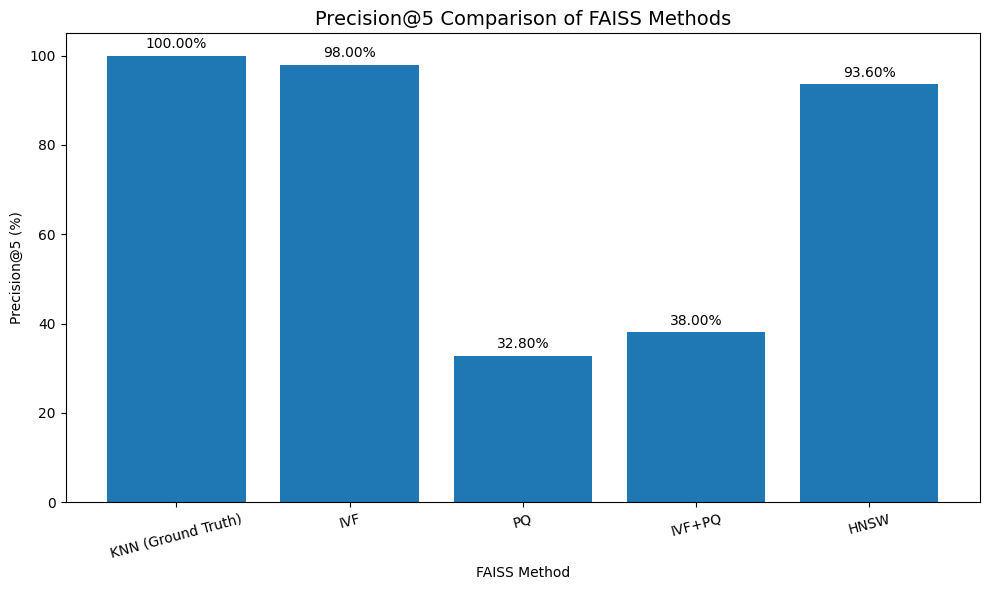

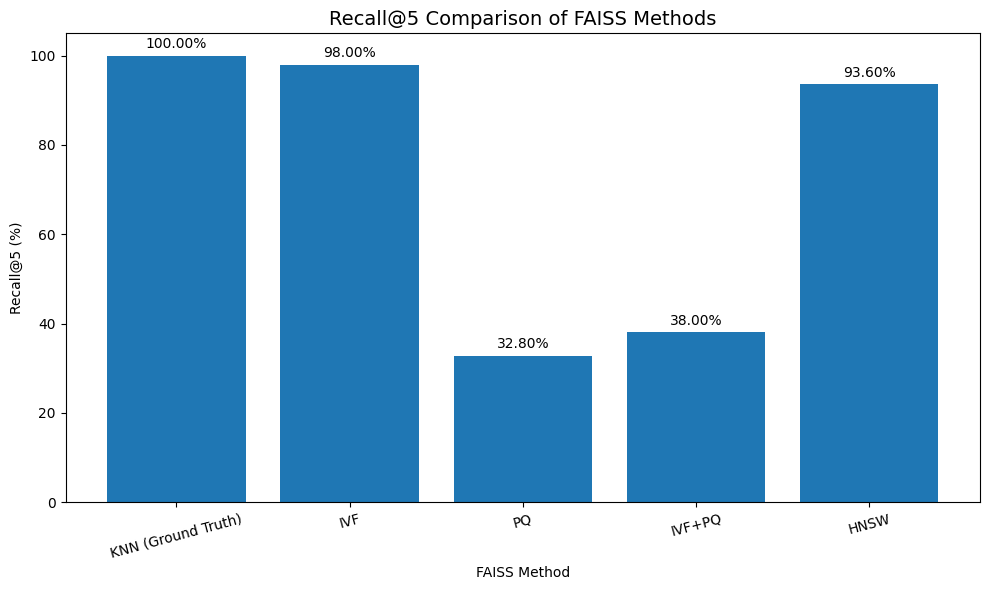

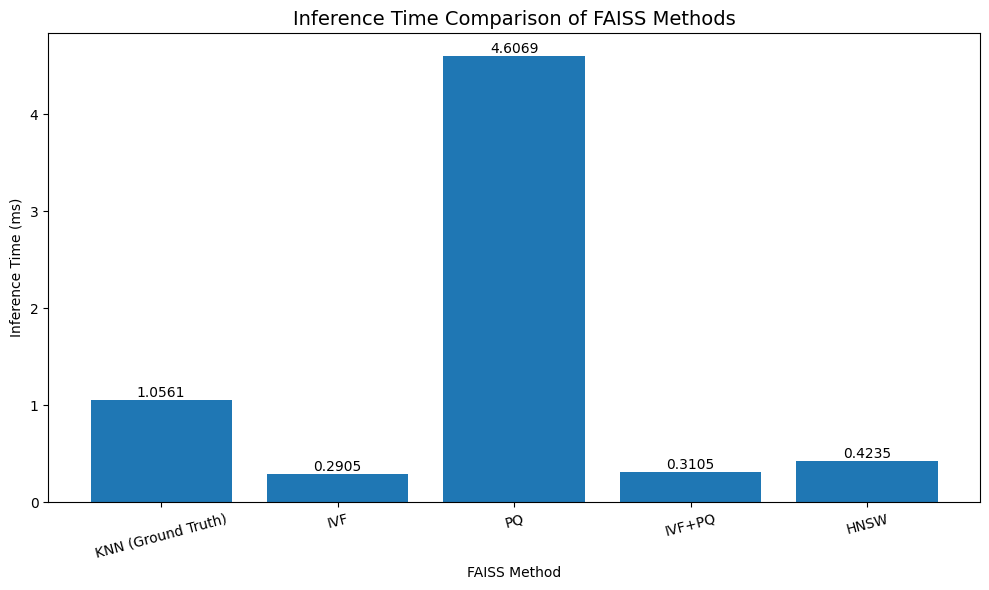

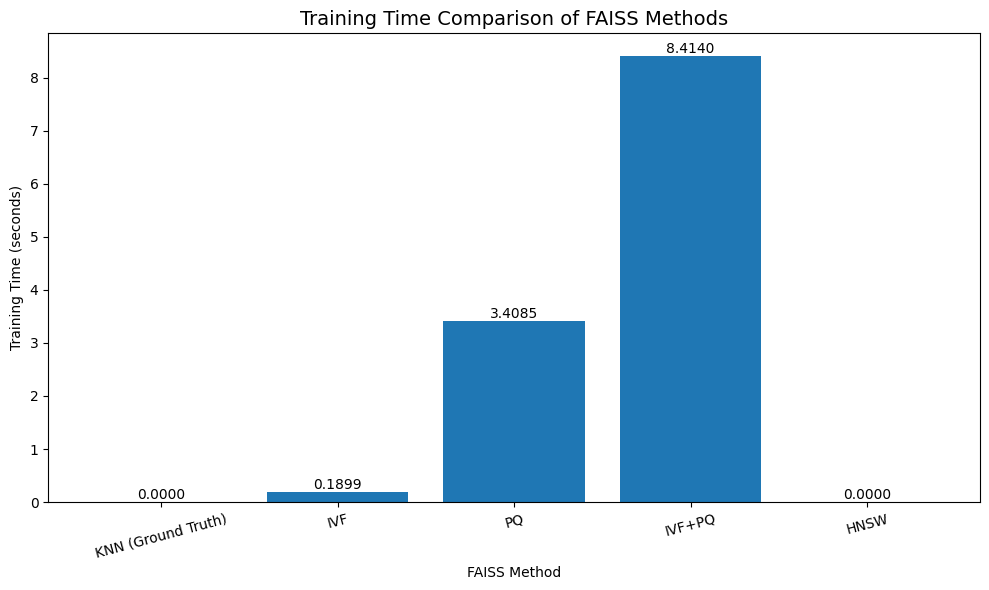

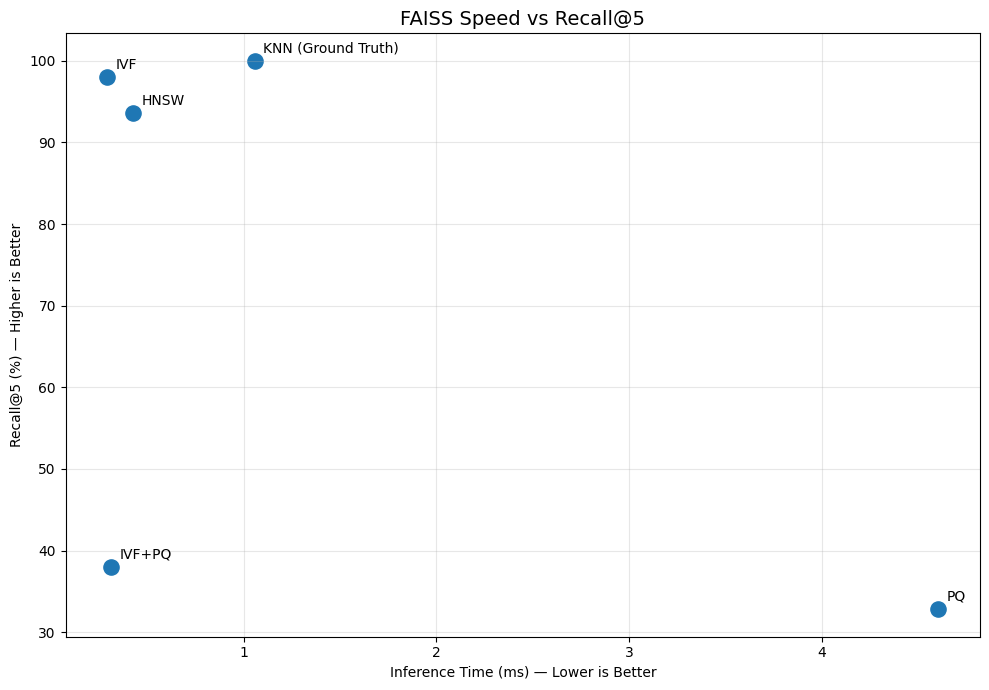

In [ ]:
# ============================================================
# FAISS PERFORMANCE GRAPHS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. Prepare data
# ============================================================

plot_df = comparison_df.copy()

# Make sure order is correct
plot_df["Method"] = plot_df["Method"].astype(str)

methods_plot = plot_df["Method"].tolist()

precision_values = plot_df[
    "Precision@5"
].values

recall_values = plot_df[
    "Recall@5"
].values

training_values = plot_df[
    "Training Time (s)"
].values

inference_values = plot_df[
    "Inference Time (ms)"
].values


# ============================================================
# 2. Precision@5
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    methods_plot,
    precision_values
)

plt.title(
    "Precision@5 Comparison of FAISS Methods",
    fontsize=14
)

plt.xlabel(
    "FAISS Method"
)

plt.ylabel(
    "Precision@5 (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=15
)

for bar, value in zip(
    bars,
    precision_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 3. Recall@5
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    methods_plot,
    recall_values
)

plt.title(
    "Recall@5 Comparison of FAISS Methods",
    fontsize=14
)

plt.xlabel(
    "FAISS Method"
)

plt.ylabel(
    "Recall@5 (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=15
)

for bar, value in zip(
    bars,
    recall_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 4. Inference Time
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    methods_plot,
    inference_values
)

plt.title(
    "Inference Time Comparison of FAISS Methods",
    fontsize=14
)

plt.xlabel(
    "FAISS Method"
)

plt.ylabel(
    "Inference Time (ms)"
)

plt.xticks(
    rotation=15
)

for bar, value in zip(
    bars,
    inference_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 5. Training Time
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    methods_plot,
    training_values
)

plt.title(
    "Training Time Comparison of FAISS Methods",
    fontsize=14
)

plt.xlabel(
    "FAISS Method"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.xticks(
    rotation=15
)

for bar, value in zip(
    bars,
    training_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 6. SPEED vs RECALL
# ============================================================
#
# X-axis = Inference Time
# Y-axis = Recall@5
#
# Lower X = faster
# Higher Y = better
#
# This is one of the most useful research graphs.
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    inference_values,
    recall_values,
    s=120
)

for x, y, method in zip(
    inference_values,
    recall_values,
    methods_plot
):

    plt.annotate(
        method,
        (
            x,
            y
        ),
        xytext=(
            6,
            6
        ),
        textcoords="offset points"
    )

plt.title(
    "FAISS Speed vs Recall@5",
    fontsize=14
)

plt.xlabel(
    "Inference Time (ms) — Lower is Better"
)

plt.ylabel(
    "Recall@5 (%) — Higher is Better"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

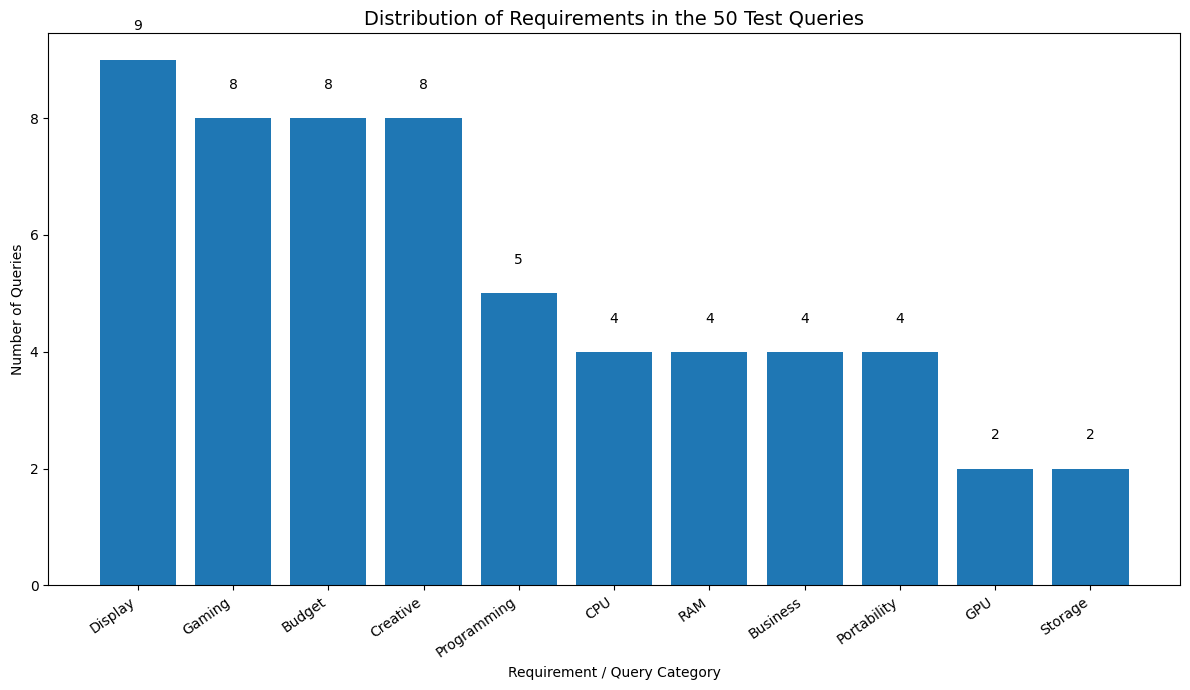

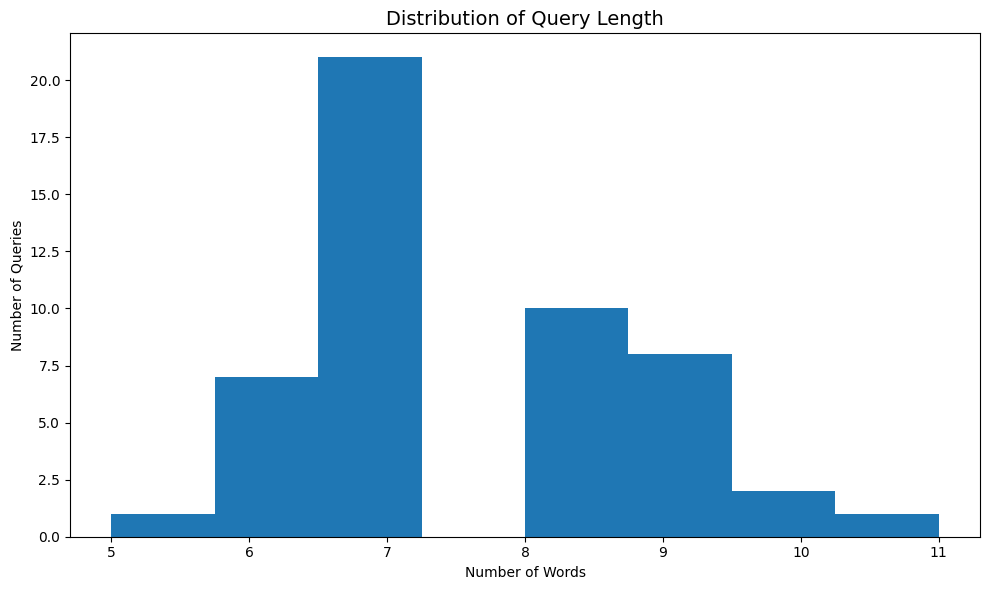

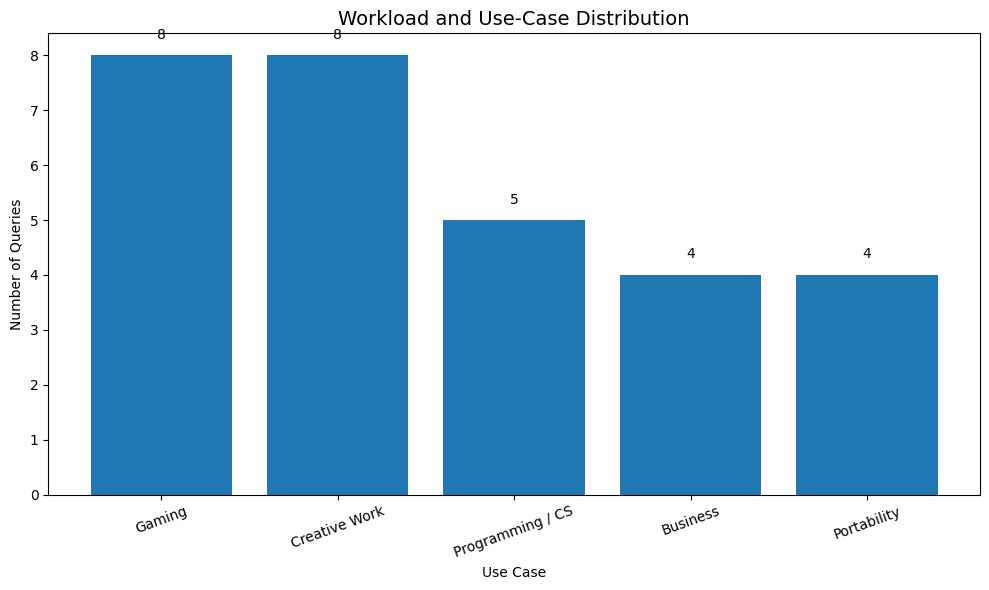



QUERY DATASET SUMMARY
Total queries              : 50
Average query length       : 7.54 words
Longest query              : 11 words
Shortest query             : 5 words

Requirement frequencies:
  Display        :  9 queries (18.0%)
  Gaming         :  8 queries (16.0%)
  Budget         :  8 queries (16.0%)
  Creative       :  8 queries (16.0%)
  Programming    :  5 queries (10.0%)
  CPU            :  4 queries (8.0%)
  RAM            :  4 queries (8.0%)
  Business       :  4 queries (8.0%)
  Portability    :  4 queries (8.0%)
  GPU            :  2 queries (4.0%)
  Storage        :  2 queries (4.0%)


In [ ]:
# ============================================================
# QUERY DATASET ANALYSIS
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE QUERY DATAFRAME
# ============================================================

query_df = pd.DataFrame({
    "Query ID": range(
        1,
        len(Query_Test) + 1
    ),
    "Query": Query_Test
})


# ============================================================
# 2. FEATURE DETECTION
# ============================================================

def contains_pattern(query, patterns):

    query_lower = query.lower()

    return any(
        re.search(
            pattern,
            query_lower
        )
        for pattern in patterns
    )


query_df["Budget"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bunder\b",
            r"\bbelow\b",
            r"\bbudget\b",
            r"\bcheap\b",
            r"\baffordable\b",
            r"\beuros?\b",
            r"€"
        ]
    )
)

query_df["RAM"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bram\b",
            r"\d+\s*gb"
        ]
    )
)

query_df["GPU"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\brtx\b",
            r"\bgtx\b",
            r"\bradeon\b",
            r"\brx\s*\d+",
            r"\bgraphics\b",
            r"\bgpu\b"
        ]
    )
)

query_df["CPU"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bintel\b",
            r"\bcore\s*i[3579]\b",
            r"\bryzen\b",
            r"\bamd\b",
            r"\bapple\s*m[1-5]\b",
            r"\bm[1-5]\s*(pro|max|ultra)?\b"
        ]
    )
)

query_df["Storage"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bssd\b",
            r"\bhdd\b",
            r"\bnvme\b",
            r"\d+\s*(gb|tb)\s*(ssd|storage)",
            r"\bstorage\b"
        ]
    )
)

query_df["Display"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\boled\b",
            r"\b240hz\b",
            r"\b\d+\s*inch\b",
            r"\bscreen\b",
            r"\bdisplay\b",
            r"\btouch\s*screen\b",
            r"\bsrgb\b",
            r"\b100\s*%\s*srgb\b"
        ]
    )
)

query_df["Portability"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\blightweight\b",
            r"\bultralight\b",
            r"\btravel\b",
            r"\bthin\b",
            r"\blong battery\b",
            r"\b1 kg\b",
            r"\b1kg\b"
        ]
    )
)

query_df["Gaming"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bgaming\b",
            r"\bminecraft\b",
            r"\bsims 4\b",
            r"\b240hz\b",
            r"\brgb\b",
            r"\bliquid cooling\b"
        ]
    )
)

query_df["Programming"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bprogramming\b",
            r"\bcoding\b",
            r"\bpython\b",
            r"\bjava\b",
            r"\bmachine learning\b",
            r"\bcyber security\b",
            r"\bethical hacking\b",
            r"\bvirtualization\b"
        ]
    )
)

query_df["Creative"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bvideo editing\b",
            r"\bpremiere\b",
            r"\bphotoshop\b",
            r"\bphotography\b",
            r"\bgraphic design\b",
            r"\bdigital art\b",
            r"\billustration\b",
            r"\bmusic production\b",
            r"\bfl studio\b",
            r"\b3d rendering\b"
        ]
    )
)

query_df["Business"] = query_df["Query"].apply(
    lambda x: contains_pattern(
        x,
        [
            r"\bbusiness\b",
            r"\baccounting\b",
            r"\bexcel\b",
            r"\bday trading\b",
            r"\bwork\b",
            r"\bremote work\b"
        ]
    )
)


# ============================================================
# 3. COUNT FEATURES
# ============================================================

feature_columns = [
    "Budget",
    "RAM",
    "GPU",
    "CPU",
    "Storage",
    "Display",
    "Portability",
    "Gaming",
    "Programming",
    "Creative",
    "Business"
]

feature_counts = (
    query_df[feature_columns]
    .sum()
    .sort_values(
        ascending=False
    )
)


# ============================================================
# GRAPH 1
# QUERY REQUIREMENT DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(12, 7)
)

bars = plt.bar(
    feature_counts.index,
    feature_counts.values
)

plt.title(
    "Distribution of Requirements in the 50 Test Queries",
    fontsize=14
)

plt.xlabel(
    "Requirement / Query Category"
)

plt.ylabel(
    "Number of Queries"
)

plt.xticks(
    rotation=35,
    ha="right"
)

for bar, value in zip(
    bars,
    feature_counts.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(value)),
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 4. QUERY COMPLEXITY
# ============================================================

query_df["Word Count"] = (
    query_df["Query"]
    .str.split()
    .str.len()
)

query_df["Constraint Count"] = (
    query_df[feature_columns]
    .sum(axis=1)
)


# ============================================================
# GRAPH 2
# QUERY LENGTH DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    query_df["Word Count"],
    bins=8
)

plt.title(
    "Distribution of Query Length",
    fontsize=14
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Number of Queries"
)

plt.tight_layout()

plt.show()



# ============================================================
# GRAPH 5
# QUERY CATEGORY PROFILE
# ============================================================

category_counts = {
    "Gaming": int(
        query_df["Gaming"].sum()
    ),

    "Programming / CS": int(
        query_df["Programming"].sum()
    ),

    "Creative Work": int(
        query_df["Creative"].sum()
    ),

    "Business": int(
        query_df["Business"].sum()
    ),

    "Portability": int(
        query_df["Portability"].sum()
    )
}

category_series = pd.Series(
    category_counts
).sort_values(
    ascending=False
)

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    category_series.index,
    category_series.values
)

plt.title(
    "Workload and Use-Case Distribution",
    fontsize=14
)

plt.xlabel(
    "Use Case"
)

plt.ylabel(
    "Number of Queries"
)

plt.xticks(
    rotation=20
)

for bar, value in zip(
    bars,
    category_series.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(value)),
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 6. SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("QUERY DATASET SUMMARY")
print("=" * 80)

print(
    f"Total queries              : {len(query_df)}"
)

print(
    f"Average query length       : "
    f"{query_df['Word Count'].mean():.2f} words"
)


print(
    f"Longest query              : "
    f"{query_df['Word Count'].max()} words"
)

print(
    f"Shortest query             : "
    f"{query_df['Word Count'].min()} words"
)

print(
    "\nRequirement frequencies:"
)

for feature, count in feature_counts.items():

    print(
        f"  {feature:15s}: "
        f"{int(count):2d} queries "
        f"({count / len(query_df) * 100:.1f}%)"
    )